# MWVCP con Max-Min Ant System (MMAS) — Report dei risultati sperimentali

Notebook di accompagnamento alla relazione. **Tutti i numeri sono calcolati al momento dai file in `results/`**
(CSV e log prodotti dagli script di `src/`): nessun valore è scritto a mano nel testo.

**Regola dei grafici.** Ogni figura viene caricata da `results/plots/` se esiste già ed è più recente dei dati da cui
deriva. Se manca, o se i dati sono stati aggiornati dopo, i grafici ricavabili dai CSV vengono rigenerati
automaticamente (file con prefisso `report_`). Le figure che richiedono di rieseguire il solver (ore di calcolo)
non vengono mai rigenerate dal notebook: sono solo mostrate, con l'indicazione dello script che le produce.

| § | Contenuto | Script / dati di origine |
|---|---|---|
| 1 | Setup, convenzioni, caricamento dati e controlli di coerenza | `results/csv/vc_*.csv` |
| 2 | Algoritmo e protocollo sperimentale | `src/core/`, `src/main.py` |
| 3 | Risultati del benchmark (per configurazione, per classe, confronto con il greedy) | `src/main.py`, `src/aggregate_results.py` |
| 4 | Convergenza | `src/analysis/plot_convergence.py` |
| 5 | Tuning dei parametri (Fase 1, multi-seed, dimensione colonia) | `src/tune_parameters.py`, `src/run_multiseed_validation.py`, `src/run_multiseed_population.py` |
| 6 | Ablation (modalità di switch, componenti) | `src/run_ablation_switch.py`, `src/analysis/plot_ablation.py` |
| 7 | Sintesi dei risultati | — |

## 1. Setup, convenzioni e caricamento dei dati

In [27]:
import sys, re, inspect
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML, Image

# --- Percorsi -----------------------------------------------------------------
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS   = PROJECT_ROOT / "results"
CSV_DIR   = RESULTS / "csv"
PLOTS_DIR = RESULTS / "plots"
LOG_DIR   = RESULTS / "log"
INST_DIR  = PROJECT_ROOT / "wvcp-instances"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Convenzioni (modificabili qui, valgono per tutto il notebook) --------------
DDOF        = 1       # deviazione standard campionaria (n-1) in TUTTE le tabelle
FE_MAX      = 20_000  # budget della consegna
FORCE_REGEN = False   # True = rigenera tutti i grafici ricavabili dai CSV
RUN_DEMO    = False   # True = esegue una run dimostrativa del solver (§2)

META = {  # prefisso -> (classe, |V|, |E|)
    "vc_20_60": ("SPI", 20, 60),     "vc_20_120": ("SPI", 20, 120),   "vc_25_150": ("SPI", 25, 150),
    "vc_100_500": ("MPI", 100, 500), "vc_100_2000": ("MPI", 100, 2000),
    "vc_200_750": ("MPI", 200, 750), "vc_200_3000": ("MPI", 200, 3000),
    "vc_800_10000": ("LPI", 800, 10000),
}
CLASS_ORDER  = ["SPI", "MPI", "LPI"]
CLASS_COLORS = {"SPI": "#43A047", "MPI": "#1E88E5", "LPI": "#FB8C00"}

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\macca\Desktop\università\magistrale\MWVC-Optimization-HEMOL


In [28]:
# --- Helper: tabelle e figure --------------------------------------------------
def sd(x):
    x = np.asarray(x, dtype=float)
    return float(np.std(x, ddof=DDOF)) if len(x) > DDOF else 0.0

def pm(x, dec=1):
    return f"{np.mean(x):.{dec}f} ± {sd(x):.{dec}f}"

def show_table(df, caption=None, note=None):
    if caption:
        display(Markdown(f"**{caption}**"))
    display(HTML(df.to_html(index=False, escape=False, border=0,
                            classes="dataframe", justify="center")))
    if note:
        display(Markdown(f"<sub>{note}</sub>"))

def _rel(p):
    try:
        return Path(p).resolve().relative_to(PROJECT_ROOT).as_posix()
    except ValueError:
        return str(p)

def save_fig(fig, path):
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.close(fig)

def figure(fname, title, sources=(), builder=None, producer=None, width=900):
    # Mostra results/plots/<fname>.
    #  - builder != None (grafico ricavabile dai CSV): rigenera se manca, se e' piu' vecchio
    #    dei file sorgente o se FORCE_REGEN=True; altrimenti usa il file salvato.
    #  - builder == None (grafico che richiede il solver): mostra il file salvato e segnala
    #    se e' piu' vecchio dei dati.
    path = PLOTS_DIR / fname
    sources = [Path(s) for s in sources]
    src_times = [s.stat().st_mtime for s in sources if s.exists()]
    newest = max(src_times) if src_times else None
    stale = path.exists() and newest is not None and path.stat().st_mtime < newest

    if builder is not None and (FORCE_REGEN or not path.exists() or stale):
        reason = "FORCE_REGEN" if (FORCE_REGEN and path.exists() and not stale) else \
                 ("file mancante" if not path.exists() else "dati sorgente piu' recenti del file")
        builder(path)
        status = f"rigenerato dai dati ({reason})"
    elif path.exists():
        status = "caricato dal file salvato"
        if stale:
            status += " — ⚠️ il file e' piu' vecchio dei dati sorgente"
    else:
        display(Markdown(f"#### {title}\n> ❌ `{_rel(path)}` non trovato. Script che lo produce: `{producer}`."))
        return

    display(Markdown(f"#### {title}"))
    display(Image(filename=str(path), width=width))
    info = [f"`{_rel(path)}`", status]
    if sources:
        info.append("dati: " + ", ".join(f"`{s.name}`" for s in sources))
    if producer:
        info.append(f"script: `{producer}`")
    display(Markdown("<sub>" + " — ".join(info) + "</sub>"))

In [29]:
# --- Caricamento dei risultati del benchmark (prodotti da src/main.py) ----------
frames = []
for prefix, (cls, n, m) in META.items():
    f = CSV_DIR / f"{prefix}.csv"
    if not f.exists():
        raise FileNotFoundError(f"CSV non trovato: {f}")

    if f.stat().st_size == 0:
        raise ValueError(
            f"Il CSV è vuoto: {f}\n"
            "Rigenera i risultati eseguendo nuovamente src/main.py."
        )

    try:
        df = pd.read_csv(f)
    except pd.errors.EmptyDataError as exc:
        raise ValueError(f"Il CSV non contiene colonne: {f}") from exc

    if df.empty or len(df.columns) == 0:
        raise ValueError(f"Il CSV non contiene dati: {f}")
    df.insert(0, "config", prefix); df.insert(0, "class", cls)
    df["n"], df["m"] = n, m
    frames.append(df)
bench = pd.concat(frames, ignore_index=True)

for col in ["opt_weight", "gap_pct_opt"]:
    bench[col] = pd.to_numeric(bench[col], errors="coerce")
bench["n_ants"]  = np.maximum(5, bench["n"] // 10)        # regola di src/main.py
bench["opt_hit"] = bench["opt_weight"].notna() & (bench["best_weight"] == bench["opt_weight"])
bench["greedy_is_best"] = bench["fe_at_best"] == 1        # FE 1 = soluzione greedy iniziale

BENCH_CSVS = [CSV_DIR / f"{p}.csv" for p in META]
print(f"{len(bench)} run caricate da {len(BENCH_CSVS)} file CSV")

80 run caricate da 8 file CSV


## 1. Introduzione del Problema

Il **Minimum Weight Vertex Cover Problem (MWVCP)** è un problema di ottimizzazione combinatoria NP-hard: Dato un grafo non orientato $G = (V, E, w)$ con pesi positivi $w_v > 0$ associati ai vertici $v \in V$, l'obiettivo è trovare un sottoinsieme di vertici $C \subseteq V$ che copra tutti gli archi $E$ minimizzando la somma dei pesi dei vertici selezionati:

$$
\begin{aligned}
\text{Minimizzare:} \quad & f(x) = \sum_{v \in V} w_v x_v \\[6pt]
\text{Soggetta a:} \quad & x_u + x_v \ge 1, \quad \forall (u, v) \in E \\[4pt]
& x_v \in \{0, 1\}, \quad \forall v \in V
\end{aligned}
$$

dove la variabile binaria $x_v = 1$ indica l'inclusione del vertice $v$ nel cover $C$ e $x_v = 0$ la sua esclusione.

### Complessità Computazionale
L'impiego di solutori esatti basati su *Branch-and-Bound* per il problema presenta una complessità elevata diventando del tutto impraticabile su grafi di grandi dimensioni.

### Gap LP (~50%)
> **Teorema di Half-Integrality**:  
> Qualsiasi punto estremo ottimale del rilassamento continuo LP del Weighted Vertex Cover è semi-intero ($x_v \in \{0, 0.5, 1\}$). Sui grafi casuali densi ed omogenei, il solutore continuo LP attribuisce il valore $x_v = 0.5$ a quasi tutti i vertici per soddisfare il vincolo di copertura $x_u + x_v = 0.5 + 0.5 = 1.0 \ge 1$, producendo un Lower Bound continuo pari a:
> $$
> \text{LB}_{\text{LP}} \approx 0.5 \cdot W_{\text{totale}}
> $$
> Poiché la soluzione discreta ammissibile richiede necessariamente $x_v \in \{0, 1\}$, si ha che:
> $$
> \text{LB}_{\text{LP}} \approx 0.5 \cdot \text{OPT}_{\text{ILP}}
> $$
> Pertanto, la presenza di un gap del ~50% tra la soluzione metaeuristica ed il Lower Bound LP non costituisce un'inefficienza dell'algoritmo MMAS, bensì rappresenta un limite teorico del rilassamento continuo.

### Vincolo del Budget Computazionale Fisso ($FE_{\max}$)
Per direttive del progetto è stato fissato il criterio di arresto di tutte le sperimentazioni rigorosamente a:
$$
FE_{\max} = 2.0 \times 10^4 = 20.000 \quad \text{valutazioni della funzione obiettivo}
$$
Ogni costruzione completa di una copertura valida da parte di una formica artificiale (comprensiva dell'eventuale fase di potatura deterministica) consuma esattamente $1 \text{ FE}$.


### Controlli di coerenza sui dati
Verifiche automatiche: se un controllo fallisce, i numeri del report non vanno usati finché non si chiarisce il motivo.

In [30]:
checks = []
def check(label, ok, detail=""):
    checks.append({"Controllo": label, "Esito": "✔" if ok else "✘", "Dettaglio": detail})

check("Ogni run ha consumato esattamente FE_max valutazioni",
      (bench["fe_used"] == FE_MAX).all(),
      f"fe_used ∈ {sorted(bench['fe_used'].unique().tolist())}")
check("Nessuna soluzione sotto il lower bound",
      (bench["best_weight"] >= bench["lower_bound"]).all())
spi = bench[bench["class"] == "SPI"]
check("SPI: ottimo ILP disponibile per ogni istanza",
      spi["opt_weight"].notna().all(), f"{spi['opt_weight'].notna().sum()}/{len(spi)}")
check("SPI: nessuna soluzione sotto l'ottimo ILP",
      (spi["best_weight"] >= spi["opt_weight"]).all())
lpi = bench[bench["class"] == "LPI"]
check("LPI: 10 run indipendenti con seed distinti",
      len(lpi) == 10 and lpi["seed"].nunique() == 10, f"seed = {lpi['seed'].tolist()}")
for p in [p for p in META if META[p][0] != "LPI"]:
    sub = bench[bench["config"] == p]
    check(f"{p}: 10 istanze distinte", sub["instance"].nunique() == 10, f"{sub['instance'].nunique()} istanze")

# confronto con il riepilogo salvato da src/aggregate_results.py
summ_path = RESULTS / "summary_by_class.csv"
if summ_path.exists():
    summ = pd.read_csv(summ_path).set_index("class")
    for c in CLASS_ORDER:
        sub = bench[bench["class"] == c]
        ok = (np.isclose(summ.loc[c, "mean_best_weight"], sub["best_weight"].mean(), atol=0.01)
              and np.isclose(summ.loc[c, "mean_fe_at_best"], sub["fe_at_best"].mean(), atol=0.1)
              and int(summ.loc[c, "n_runs"]) == len(sub))
        check(f"{c}: coerente con results/summary_by_class.csv", ok)

show_table(pd.DataFrame(checks), "Tabella di controllo coerenza")

**Tabella di controllo coerenza**

Controllo,Esito,Dettaglio
Ogni run ha consumato esattamente FE_max valutazioni,✔,fe_used ∈ [20000]
Nessuna soluzione sotto il lower bound,✔,
SPI: ottimo ILP disponibile per ogni istanza,✔,30/30
SPI: nessuna soluzione sotto l'ottimo ILP,✔,
LPI: 10 run indipendenti con seed distinti,✔,"seed = [49, 91, 133, 175, 217, 259, 301, 343, 385, 427]"
vc_20_60: 10 istanze distinte,✔,10 istanze
vc_20_120: 10 istanze distinte,✔,10 istanze
vc_25_150: 10 istanze distinte,✔,10 istanze
vc_100_500: 10 istanze distinte,✔,10 istanze
vc_100_2000: 10 istanze distinte,✔,10 istanze


## 2. Algoritmo e protocollo sperimentale

**Problema.** Dato $G=(V,E)$ con pesi $w_v>0$, si cerca $C\subseteq V$ che copra ogni arco minimizzando $\sum_{v\in C} w_v$:
$$
\min \sum_{v\in V} w_v x_v \quad \text{s.t.}\quad x_u + x_v \ge 1\ \ \forall (u,v)\in E,\qquad x_v\in\{0,1\}.
$$

**Componenti dell'algoritmo** (package `src/core/`):

| Componente | File | Descrizione |
|---|---|---|
| Soluzione iniziale | `mmas.py` | Greedy deterministico: sceglie il vertice con massimo $d_{\text{uncov}}(v)/w_v$, poi pruning. Conta come 1 FE. |
| Feromone sui vertici | `pheromone.py` | $\tau_v\in[\tau_{\min},\tau_{\max}]$, $\tau_{\max}=1/(\rho\, w(S_{gb}))$, $\tau_{\min}=\tau_{\max}/(2\lvert V\rvert)$, aggiornati a ogni nuovo $S_{gb}$. |
| Euristica | `ant.py` | $\eta_v = d_{\text{uncov}}(v)^{\gamma}/w_v$ con $\gamma=1$, ricalcolata a ogni passo della costruzione. |
| Regola di scelta | `ant.py` | $p_v \propto \tau_v^{\alpha}\,\eta_v^{\beta}$ sui vertici con $d_{\text{uncov}}(v)>0$ (roulette-wheel). |
| Pruning (daemon action) | `pruning.py` | Rimuove i vertici ridondanti in ordine di peso decrescente → copertura minimale. |
| Deposito | `mmas.py` | Evaporazione $(1-\rho)\tau_v$, deposito $1/w(S_{guide})$ sui vertici di $S_{guide}$, clamping. |
| Scelta di $S_{guide}$ | `mmas.py` | `gb_switch_mode="cycle"`: $S_{ib}$ se $k_{stg}/Stg_{limit} < 0.75$, altrimenti $S_{gb}$. |
| Reset per stagnazione | `mmas.py` | Dopo $Stg_{limit}$ iterazioni senza miglioramento: $\tau_v\leftarrow\tau_{\max}$, $k_{stg}\leftarrow 0$. |
| Arresto | `mmas.py`, `evaluator.py` | Budget di $FE_{\max}=20\,000$ oppure raggiunto il numero massimo di reset (`max_reinits`). |

**Parametri adattivi** (calcolati in `main.py` e `mmas.py`):
- $N_{ants}=\max(5,\lfloor n/10\rfloor)$, 
- $I=\lfloor FE_{\max}/N_{ants}\rfloor$,
- $Stg_{limit}=\max(20,\min(200,\lfloor I/10\rfloor))$, 
- $\texttt{max\_reinits}=\max(3,\lfloor I/Stg_{limit}\rfloor)$.

**Parametri fissati** (`SOLVER_PARAMS` in `src/main.py`): $\alpha=1.0$, $\beta=2.0$, $\rho=0.10$, $\gamma=1.0$, pruning greedy.

**Riferimenti di qualità** (`src/core/exact_solver.py`):
- SPI: ottimo esatto via ILP (`scipy.optimize.milp`, solver HiGHS, limite 60 s per istanza).
- Tutte le classi: *lower bound* da **matching greedy**, $LB=\sum_{(u,v)\in M}\min(w_u,w_v)$ per un matching $M$.
  È un limite inferiore valido ma debole: il gap rispetto a $LB$ misura la debolezza del bound tanto quanto la qualità della soluzione.
- Gap: $\text{gap}=(w-\text{ref})/\text{ref}\cdot 100$, calcolato per istanza (o per run) e poi mediato.

In [31]:
# --- Tabella 2.1: protocollo effettivamente eseguito (ricavato dai CSV) ----------
rows = []
for p, (cls, n, m) in META.items():
    sub = bench[bench["config"] == p]
    n_ants = max(5, n // 10)
    I = FE_MAX // n_ants
    stg = max(20, min(200, I // 10))
    rows.append({
        "Classe": cls, "Config": p, "|V|": n, "|E|": m,
        "Istanze": sub["instance"].nunique(),
        "Run/istanza": int(len(sub) / sub["instance"].nunique()),
        "Seed": ", ".join(map(str, sorted(sub["seed"].unique()))),
        "N_ants": n_ants, "Iterazioni": int(sub["iterations"].median()),
        "Stg_limit": stg, "max_reinits": max(3, I // stg),
        "Reset medi": round(sub["n_reinits"].mean(), 1),
    })
show_table(pd.DataFrame(rows), "Tabella 2.1 — Protocollo sperimentale (dai CSV del benchmark)",
           "SPI/MPI: 10 istanze distinte, 1 run ciascuna (seed 42). LPI: 1 istanza, 10 run indipendenti "
           "(seed = 42·k + 7). Iterazioni = FE_max / N_ants.")

**Tabella 2.1 — Protocollo sperimentale (dai CSV del benchmark)**

Classe,Config,|V|,|E|,Istanze,Run/istanza,Seed,N_ants,Iterazioni,Stg_limit,max_reinits,Reset medi
SPI,vc_20_60,20,60,10,1,42,5,4000,200,20,19.7
SPI,vc_20_120,20,120,10,1,42,5,4000,200,20,19.7
SPI,vc_25_150,25,150,10,1,42,5,4000,200,20,19.7
MPI,vc_100_500,100,500,10,1,42,10,2000,200,10,9.0
MPI,vc_100_2000,100,2000,10,1,42,10,2000,200,10,9.0
MPI,vc_200_750,200,750,10,1,42,20,1000,100,10,8.8
MPI,vc_200_3000,200,3000,10,1,42,20,1000,100,10,8.8
LPI,vc_800_10000,800,10000,1,10,"49, 91, 133, 175, 217, 259, 301, 343, 385, 427",80,250,25,10,7.3


<sub>SPI/MPI: 10 istanze distinte, 1 run ciascuna (seed 42). LPI: 1 istanza, 10 run indipendenti (seed = 42·k + 7). Iterazioni = FE_max / N_ants.</sub>

In [32]:
# --- Demo facoltativa: una run del solver con la configurazione del benchmark ----
if RUN_DEMO:
    from src.core.graph import Graph
    from src.core.mmas import MMAS_Solver
    demo_path = INST_DIR / "vc_20_120_05.txt"
    G = Graph.load_from_file(str(demo_path))
    solver = MMAS_Solver(G, alpha=1.0, beta=2.0, rho=0.10, n_ants=max(5, G.n // 10),
                         max_fe=FE_MAX, pruning_strategy="greedy", seed=42)
    res = solver.solve()
    print(f"{demo_path.name}: w = {res['best_weight']:.0f}, FE al best = {res['fe_at_best']}, "
          f"reset = {res['n_reinits']}, tempo = {res['time_s']:.1f} s")
else:
    print("Demo disattivata (RUN_DEMO = False).")

Demo disattivata (RUN_DEMO = False).


## 3. Risultati del benchmark

Come richiesto dalla consegna: **(1)** media delle migliori soluzioni sulle 10 istanze (SPI, MPI) o sulle 10 run (LPI);
**(2)** numero medio di valutazioni necessarie per raggiungere la migliore soluzione trovata ($FE_{best}$).

Per SPI e MPI la deviazione standard misura la variabilità **tra istanze diverse**, non la variabilità stocastica
dell'algoritmo; per LPI misura la variabilità **tra run** sulla stessa istanza.

In [33]:
# --- Tabella 3.1: risultati per configurazione ---------------------------------
rows = []
for p, (cls, n, m) in META.items():
    sub = bench[bench["config"] == p]
    is_spi = cls == "SPI"
    rows.append({
        "Classe": cls, "Config": p, "|V|": n, "|E|": m, "N": len(sub),
        "Media w ± σ": pm(sub["best_weight"]),
        "Min w": int(sub["best_weight"].min()), "Max w": int(sub["best_weight"].max()),
        "Riferimento": "OPT (ILP)" if is_spi else "LB matching",
        "Rif. medio": round((sub["opt_weight"] if is_spi else sub["lower_bound"]).mean(), 1),
        "Gap medio %": round((sub["gap_pct_opt"] if is_spi else sub["gap_pct_lb"]).mean(), 2),
        "OPT raggiunti": f"{int(sub['opt_hit'].sum())}/{len(sub)}" if is_spi else "—",
        "FE_best ± σ": pm(sub["fe_at_best"]),
        "Best = greedy": f"{int(sub['greedy_is_best'].sum())}/{len(sub)}",
        "Tempo medio (s)": round(sub["time_seconds"].mean(), 1),
    })
table_config = pd.DataFrame(rows)
show_table(table_config, "Tabella 3.1 — Risultati per configurazione (FE_max = 20 000)",
           f"σ con ddof={DDOF}. N = istanze (SPI/MPI) o run (LPI). "
           "«Best = greedy»: run in cui la soluzione finale è quella greedy iniziale (FE_best = 1).")

rows_det = bench[["class", "config", "instance", "seed", "best_weight", "opt_weight", "lower_bound",
                  "gap_pct_lb", "fe_at_best", "n_reinits", "time_seconds"]].copy()
rows_det["opt_weight"] = rows_det["opt_weight"].map(lambda v: "—" if pd.isna(v) else int(v))
display(HTML("<details><summary><b>Dettaglio per istanza / run (80 righe)</b></summary>"
             + rows_det.to_html(index=False, border=0) + "</details>"))

**Tabella 3.1 — Risultati per configurazione (FE_max = 20 000)**

Classe,Config,|V|,|E|,N,Media w ± σ,Min w,Max w,Riferimento,Rif. medio,Gap medio %,OPT raggiunti,FE_best ± σ,Best = greedy,Tempo medio (s)
SPI,vc_20_60,20,60,10,861.8 ± 87.2,730,980,OPT (ILP),861.8,0.00,10/10,7.3 ± 6.8,2/10,15.3
SPI,vc_20_120,20,120,10,1038.2 ± 115.4,844,1261,OPT (ILP),1038.2,0.00,10/10,6.0 ± 8.6,5/10,12.1
SPI,vc_25_150,25,150,10,1264.0 ± 123.9,1061,1450,OPT (ILP),1264.0,0.00,10/10,7.3 ± 13.6,5/10,16.1
MPI,vc_100_500,100,500,10,4607.7 ± 161.2,4370,4872,LB matching,3102.0,48.60,—,3080.0 ± 2661.0,0/10,74.8
MPI,vc_100_2000,100,2000,10,6051.9 ± 197.7,5738,6297,LB matching,3410.6,77.44,—,723.6 ± 1355.9,0/10,131.0
MPI,vc_200_750,200,750,10,8273.3 ± 321.4,7635,8761,LB matching,5924.4,39.71,—,3762.1 ± 4520.8,0/10,104.9
MPI,vc_200_3000,200,3000,10,11599.1 ± 394.3,11121,12549,LB matching,6798.9,70.59,—,4626.2 ± 6165.4,0/10,161.5
LPI,vc_800_10000,800,10000,10,44489.9 ± 78.9,44428,44694,LB matching,26800.0,66.01,—,5776.9 ± 4955.4,0/10,1438.5


<sub>σ con ddof=1. N = istanze (SPI/MPI) o run (LPI). «Best = greedy»: run in cui la soluzione finale è quella greedy iniziale (FE_best = 1).</sub>

class,config,instance,seed,best_weight,opt_weight,lower_bound,gap_pct_lb,fe_at_best,n_reinits,time_seconds
SPI,vc_20_60,vc_20_60_01.txt,42,773,773,550,40.55,12,19,9.980
SPI,vc_20_60,vc_20_60_02.txt,42,938,938,656,42.99,5,20,9.325
SPI,vc_20_60,vc_20_60_03.txt,42,730,730,538,35.69,6,20,9.760
SPI,vc_20_60,vc_20_60_04.txt,42,757,757,578,30.97,10,19,10.200
SPI,vc_20_60,vc_20_60_05.txt,42,871,871,539,61.60,4,20,10.641
SPI,vc_20_60,vc_20_60_06.txt,42,855,855,562,52.14,4,20,13.753
SPI,vc_20_60,vc_20_60_07.txt,42,972,972,620,56.77,24,19,26.563
SPI,vc_20_60,vc_20_60_08.txt,42,867,867,672,29.02,1,20,26.804
SPI,vc_20_60,vc_20_60_09.txt,42,980,980,700,40.00,6,20,18.938
SPI,vc_20_60,vc_20_60_10.txt,42,875,875,618,41.59,1,20,17.089


In [34]:
# --- Tabella 3.2: risultati aggregati per classe --------------------------------
rows = []
for c in CLASS_ORDER:
    sub = bench[bench["class"] == c]
    gap = sub["gap_pct_opt"] if c == "SPI" else sub["gap_pct_lb"]
    rows.append({
        "Classe": c, "Config": sub["config"].nunique(), "Run totali": len(sub),
        "Riferimento": "OPT (ILP)" if c == "SPI" else "LB matching",
        "Gap medio %": round(gap.mean(), 2),
        "OPT raggiunti": f"{int(sub['opt_hit'].sum())}/{len(sub)}" if c == "SPI" else "—",
        "FE_best ± σ": pm(sub["fe_at_best"]),
        "FE_best / FE_max (%)": round(sub["fe_at_best"].mean() / FE_MAX * 100, 2),
        "Best = greedy": f"{int(sub['greedy_is_best'].sum())}/{len(sub)}",
        "Reset medi": round(sub["n_reinits"].mean(), 1),
        "Tempo medio (s)": pm(sub["time_seconds"]),
    })
table_class = pd.DataFrame(rows)
show_table(table_class, "Tabella 3.2 — Risultati aggregati per classe",
           "Il peso medio non è riportato a livello di classe perché mescolerebbe grafi di dimensioni diverse; "
           "gap, FE e tempi sono invece confrontabili.")

**Tabella 3.2 — Risultati aggregati per classe**

Classe,Config,Run totali,Riferimento,Gap medio %,OPT raggiunti,FE_best ± σ,FE_best / FE_max (%),Best = greedy,Reset medi,Tempo medio (s)
SPI,3,30,OPT (ILP),0.00,30/30,6.9 ± 9.7,0.03,12/30,19.7,14.5 ± 4.3
MPI,4,40,LB matching,59.09,—,3048.0 ± 4207.4,15.24,0/40,8.9,118.1 ± 34.7
LPI,1,10,LB matching,66.01,—,5776.9 ± 4955.4,28.88,0/10,7.3,1438.5 ± 449.7


<sub>Il peso medio non è riportato a livello di classe perché mescolerebbe grafi di dimensioni diverse; gap, FE e tempi sono invece confrontabili.</sub>

### 3.1 Confronto con la soluzione greedy iniziale
Il greedy è deterministico e costa pochi millisecondi, quindi viene ricalcolato qui per ogni istanza
(ed è salvato in `results/csv/greedy_baseline.csv` per non ripeterlo). Misura quanto MMAS migliora la soluzione di partenza.

In [35]:
from src.core.graph import Graph
from src.core.mmas import MMAS_Solver

greedy_csv = CSV_DIR / "greedy_baseline.csv"
if greedy_csv.exists() and not FORCE_REGEN:
    greedy = pd.read_csv(greedy_csv)
    print(f"Baseline greedy caricata da {_rel(greedy_csv)}")
else:
    recs = []
    for inst in sorted(bench["instance"].unique()):
        g = Graph.load_from_file(str(INST_DIR / inst))
        s = MMAS_Solver(g, pruning_strategy="greedy")._construct_initial_solution(np.random.default_rng(0))
        recs.append({"instance": inst, "greedy_weight": float(s.weight)})
    greedy = pd.DataFrame(recs)
    greedy.to_csv(greedy_csv, index=False)
    print(f"Baseline greedy calcolata e salvata in {_rel(greedy_csv)}")

bench = bench.drop(columns=["greedy_weight"], errors="ignore").merge(greedy, on="instance", how="left")
bench["impr_pct"] = (bench["greedy_weight"] - bench["best_weight"]) / bench["greedy_weight"] * 100

rows = []
for p, (cls, n, m) in META.items():
    sub = bench[bench["config"] == p]
    rows.append({
        "Classe": cls, "Config": p,
        "Greedy medio": round(sub["greedy_weight"].mean(), 1),
        "MMAS medio": round(sub["best_weight"].mean(), 1),
        "Miglioramento medio %": round(sub["impr_pct"].mean(), 2),
        "Run migliorate": f"{int((sub['impr_pct'] > 0).sum())}/{len(sub)}",
    })
table_greedy = pd.DataFrame(rows)
show_table(table_greedy, "Tabella 3.3 — MMAS rispetto alla soluzione greedy iniziale",
           "Miglioramento % = (w_greedy − w_MMAS) / w_greedy · 100, calcolato per istanza/run e poi mediato.")

Baseline greedy caricata da results/csv/greedy_baseline.csv


**Tabella 3.3 — MMAS rispetto alla soluzione greedy iniziale**

Classe,Config,Greedy medio,MMAS medio,Miglioramento medio %,Run migliorate
SPI,vc_20_60,885.9,861.8,2.58,8/10
SPI,vc_20_120,1057.9,1038.2,1.88,5/10
SPI,vc_25_150,1306.4,1264.0,3.01,5/10
MPI,vc_100_500,4804.5,4607.7,4.08,10/10
MPI,vc_100_2000,6167.5,6051.9,1.86,10/10
MPI,vc_200_750,8490.2,8273.3,2.53,10/10
MPI,vc_200_3000,11851.9,11599.1,2.12,10/10
LPI,vc_800_10000,45777.0,44489.9,2.81,10/10


<sub>Miglioramento % = (w_greedy − w_MMAS) / w_greedy · 100, calcolato per istanza/run e poi mediato.</sub>

#### Figura 3.1 — Migliori soluzioni per configurazione

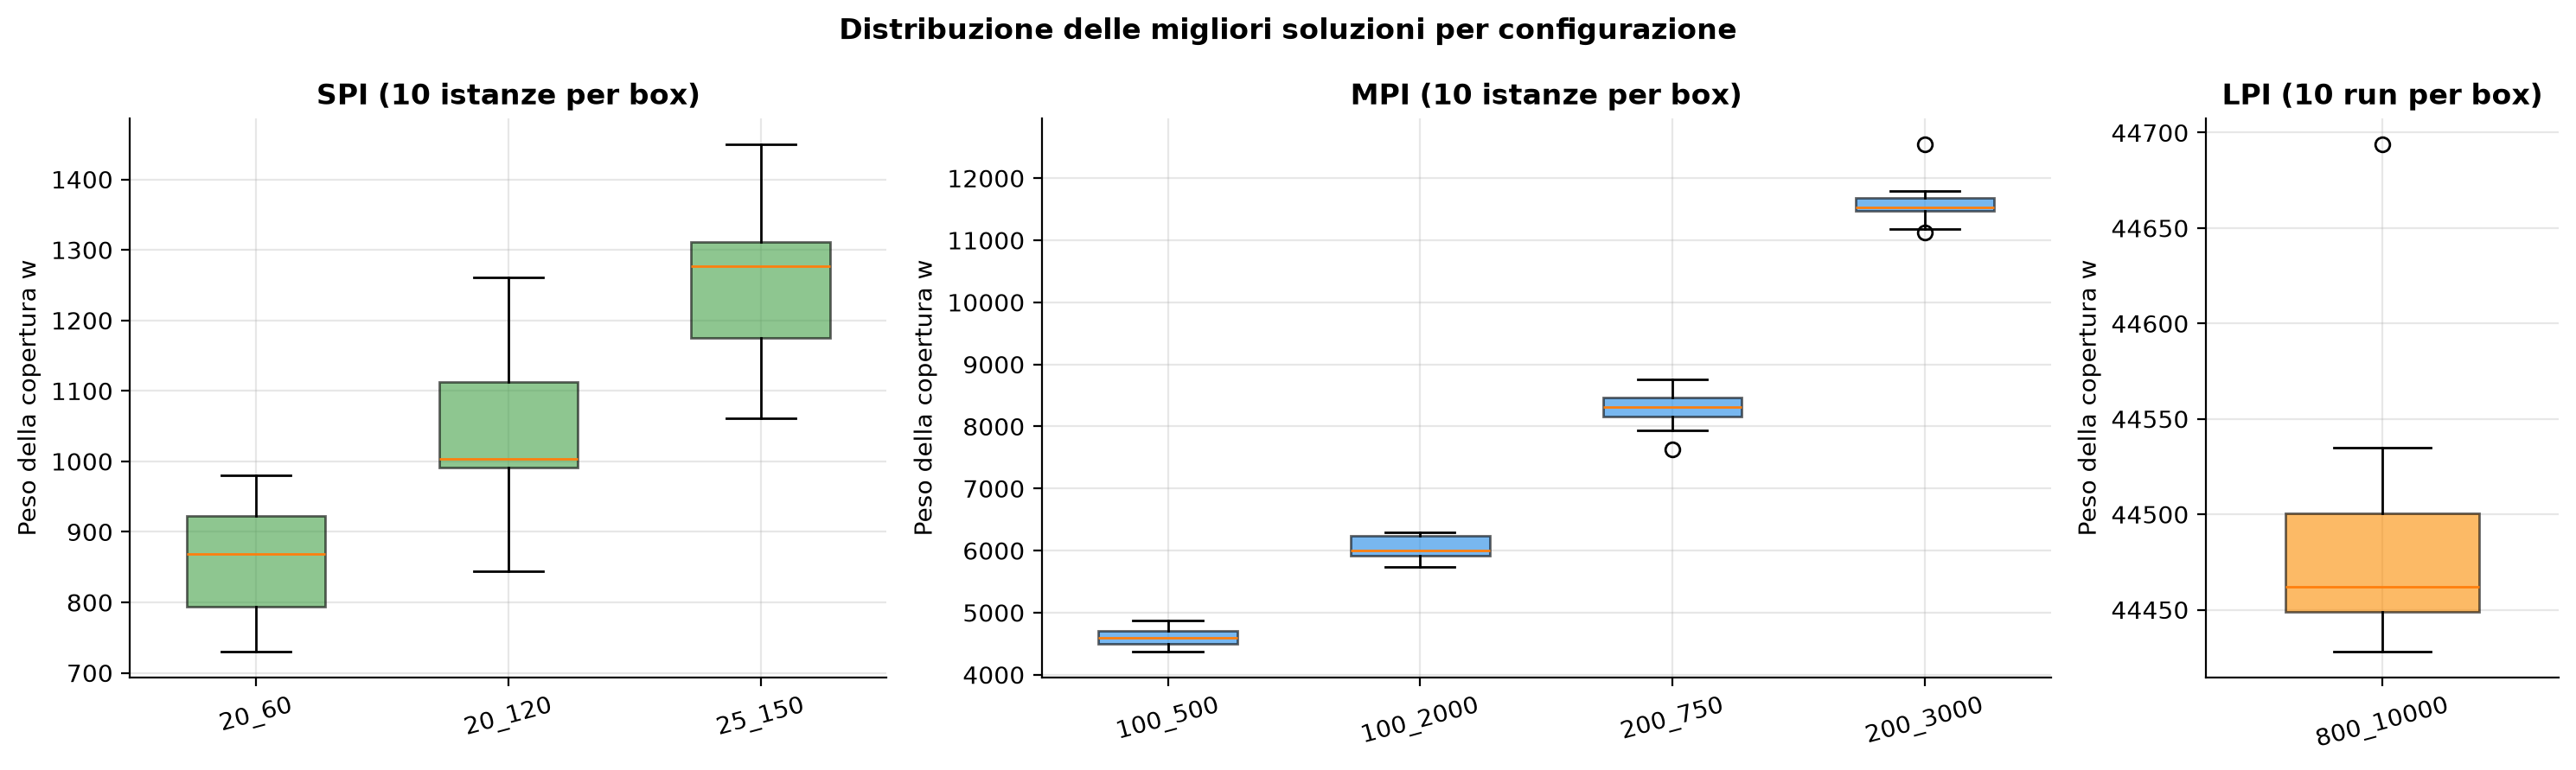

<sub>`results/plots/report_boxplot_best_weight.png` — caricato dal file salvato — dati: `vc_20_60.csv`, `vc_20_120.csv`, `vc_25_150.csv`, `vc_100_500.csv`, `vc_100_2000.csv`, `vc_200_750.csv`, `vc_200_3000.csv`, `vc_800_10000.csv`</sub>

#### Figura 3.2 — FE al best e posizione nel budget

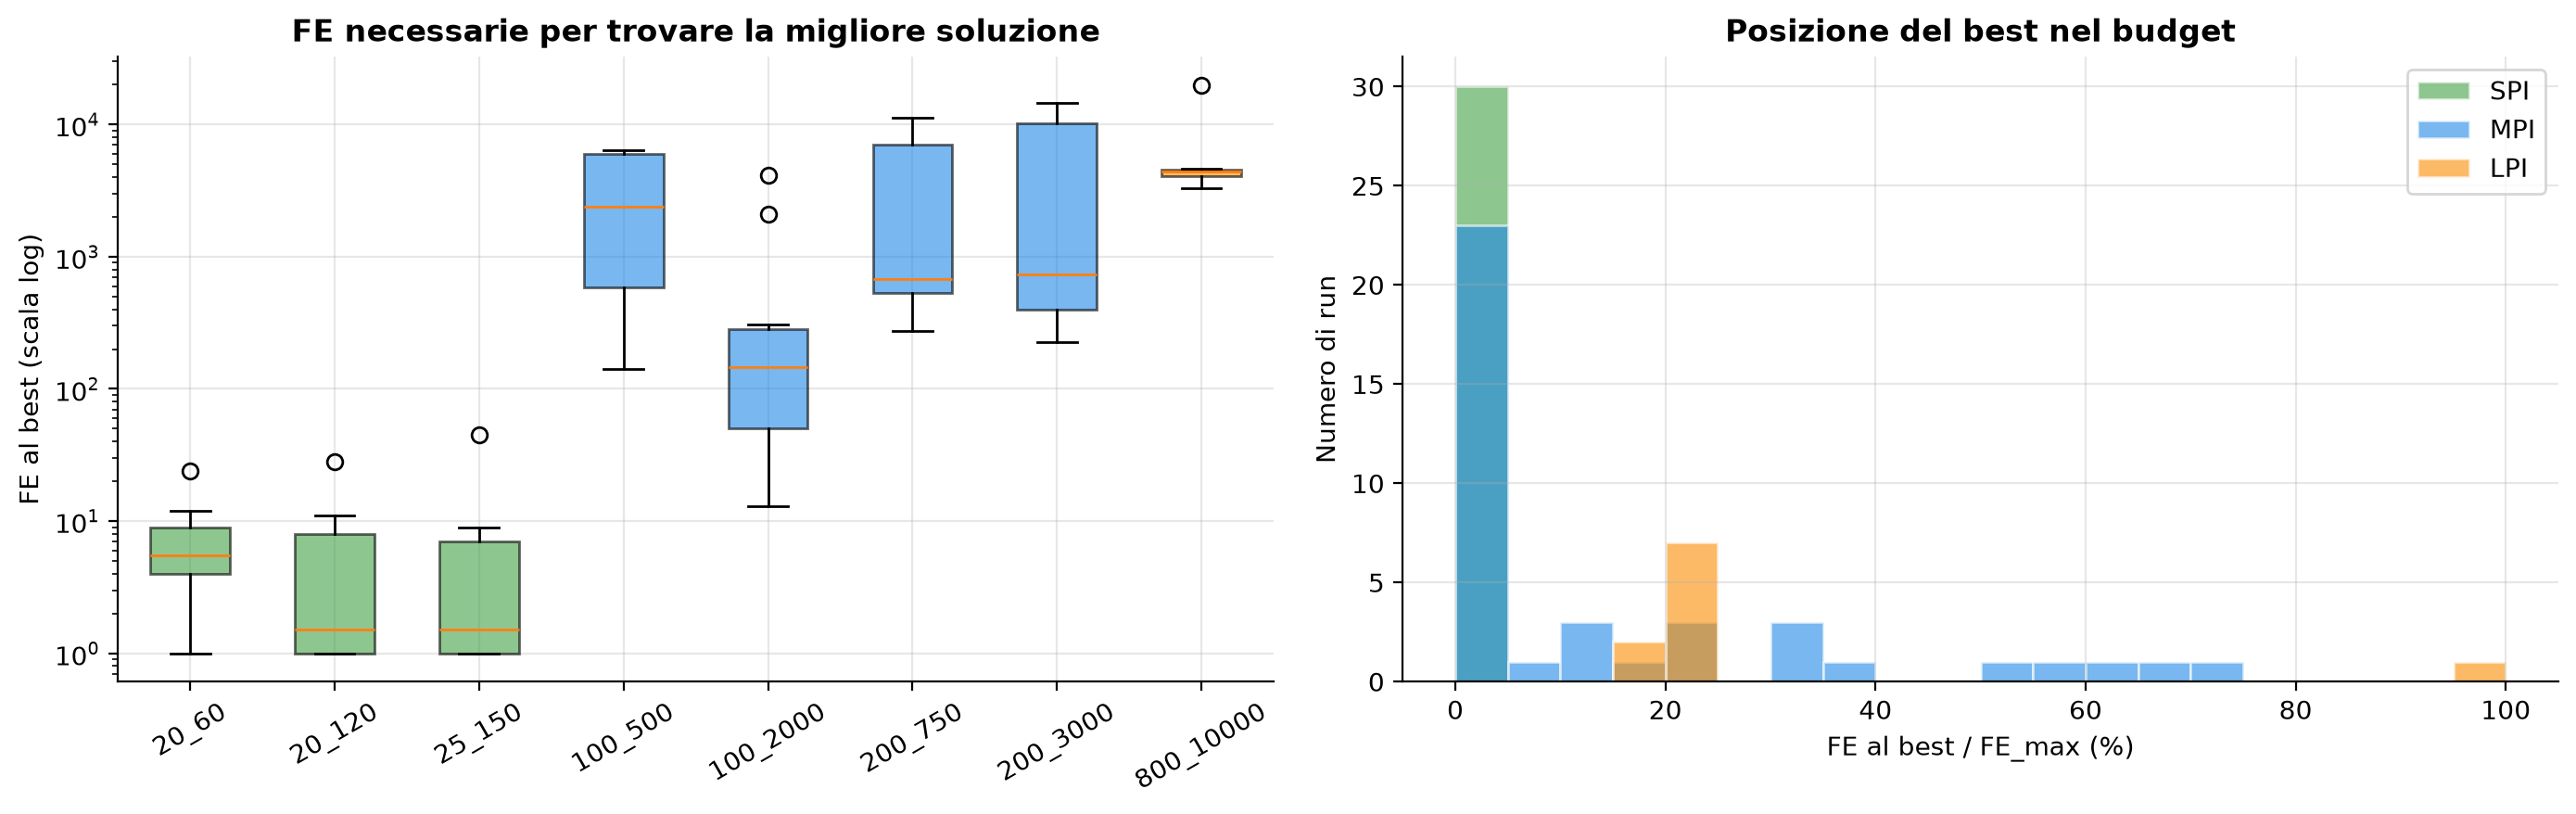

<sub>`results/plots/report_fe_distribution.png` — caricato dal file salvato — dati: `vc_20_60.csv`, `vc_20_120.csv`, `vc_25_150.csv`, `vc_100_500.csv`, `vc_100_2000.csv`, `vc_200_750.csv`, `vc_200_3000.csv`, `vc_800_10000.csv`</sub>

#### Figura 3.3 — Scalabilità: tempo e FE rispetto a |V|

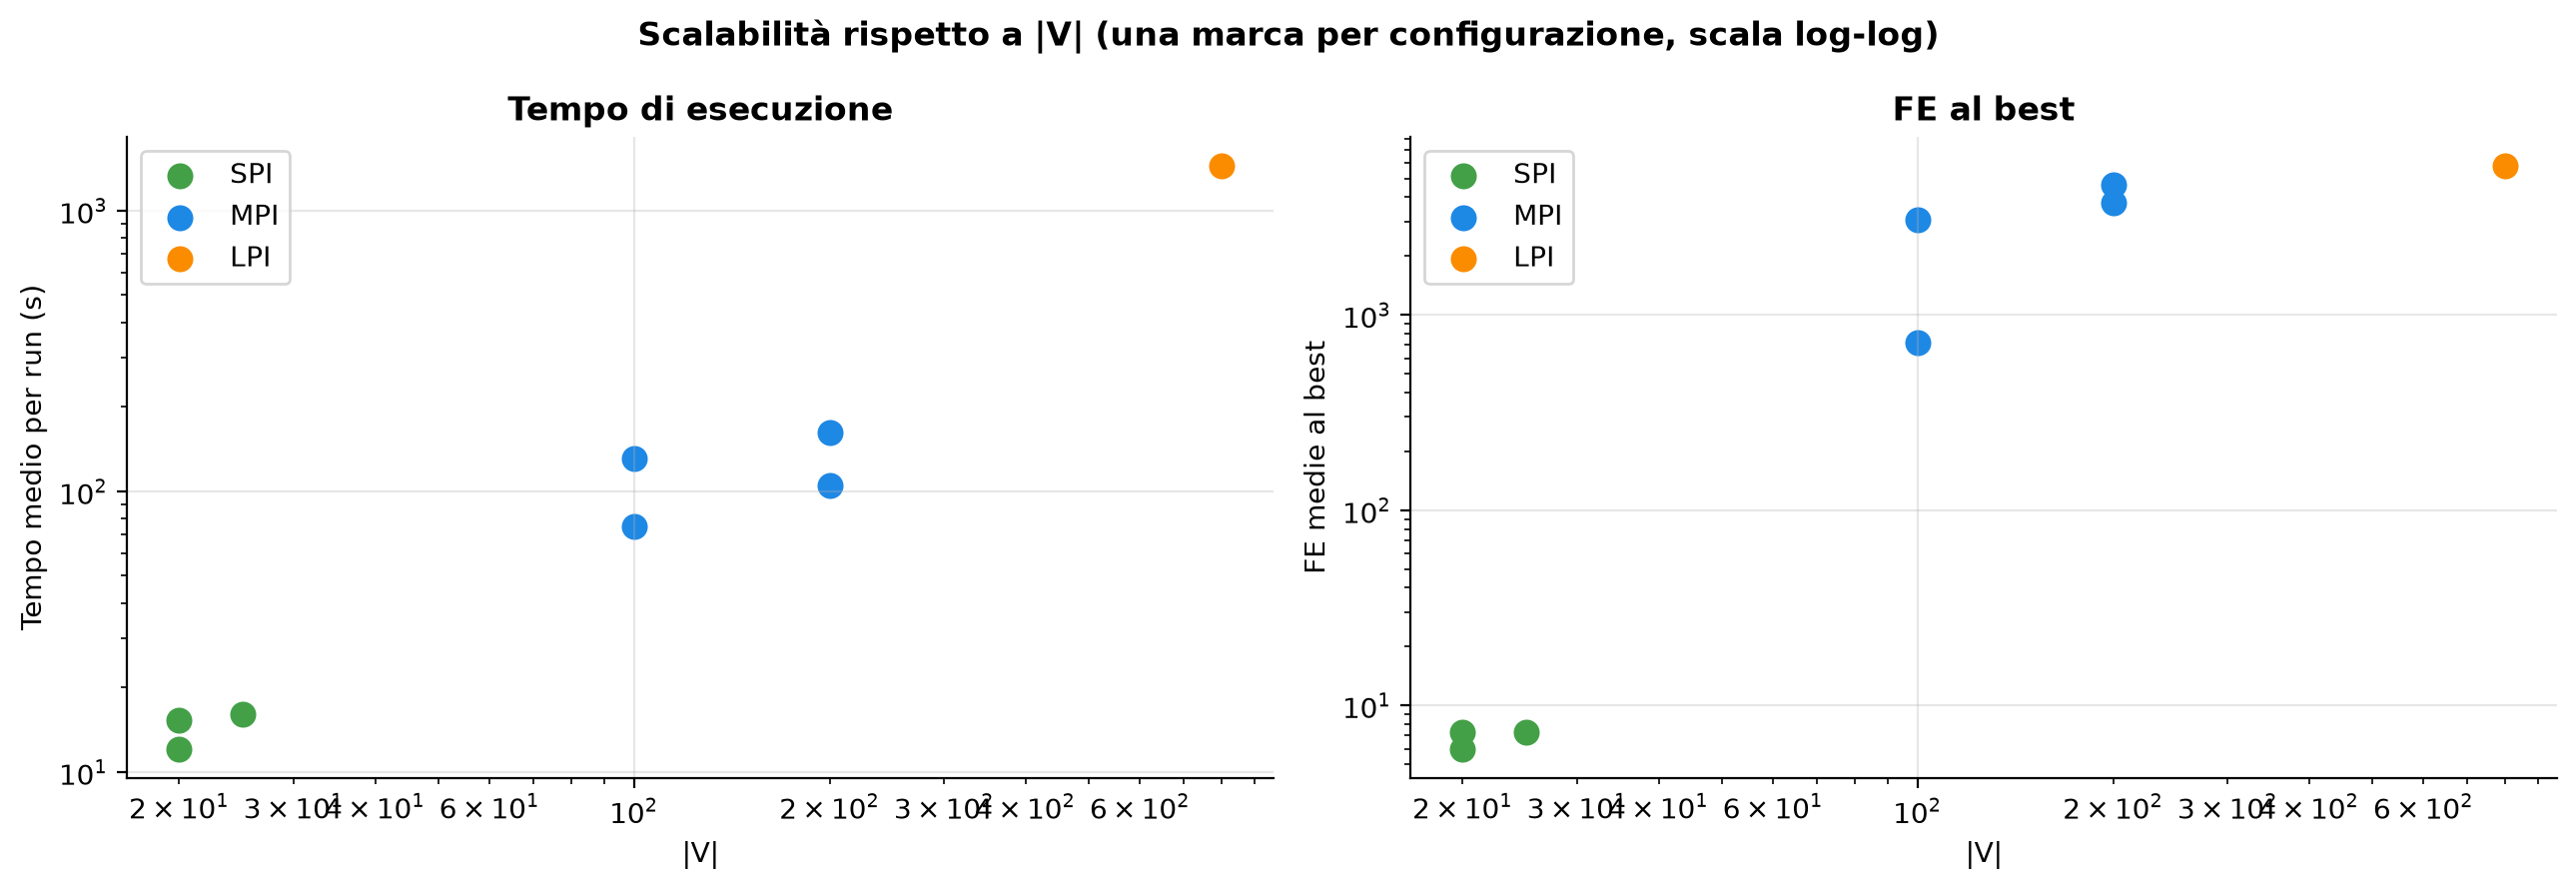

<sub>`results/plots/report_scalability.png` — caricato dal file salvato — dati: `vc_20_60.csv`, `vc_20_120.csv`, `vc_25_150.csv`, `vc_100_500.csv`, `vc_100_2000.csv`, `vc_200_750.csv`, `vc_200_3000.csv`, `vc_800_10000.csv`</sub>

#### Figura 3.4 — Miglioramento rispetto al greedy

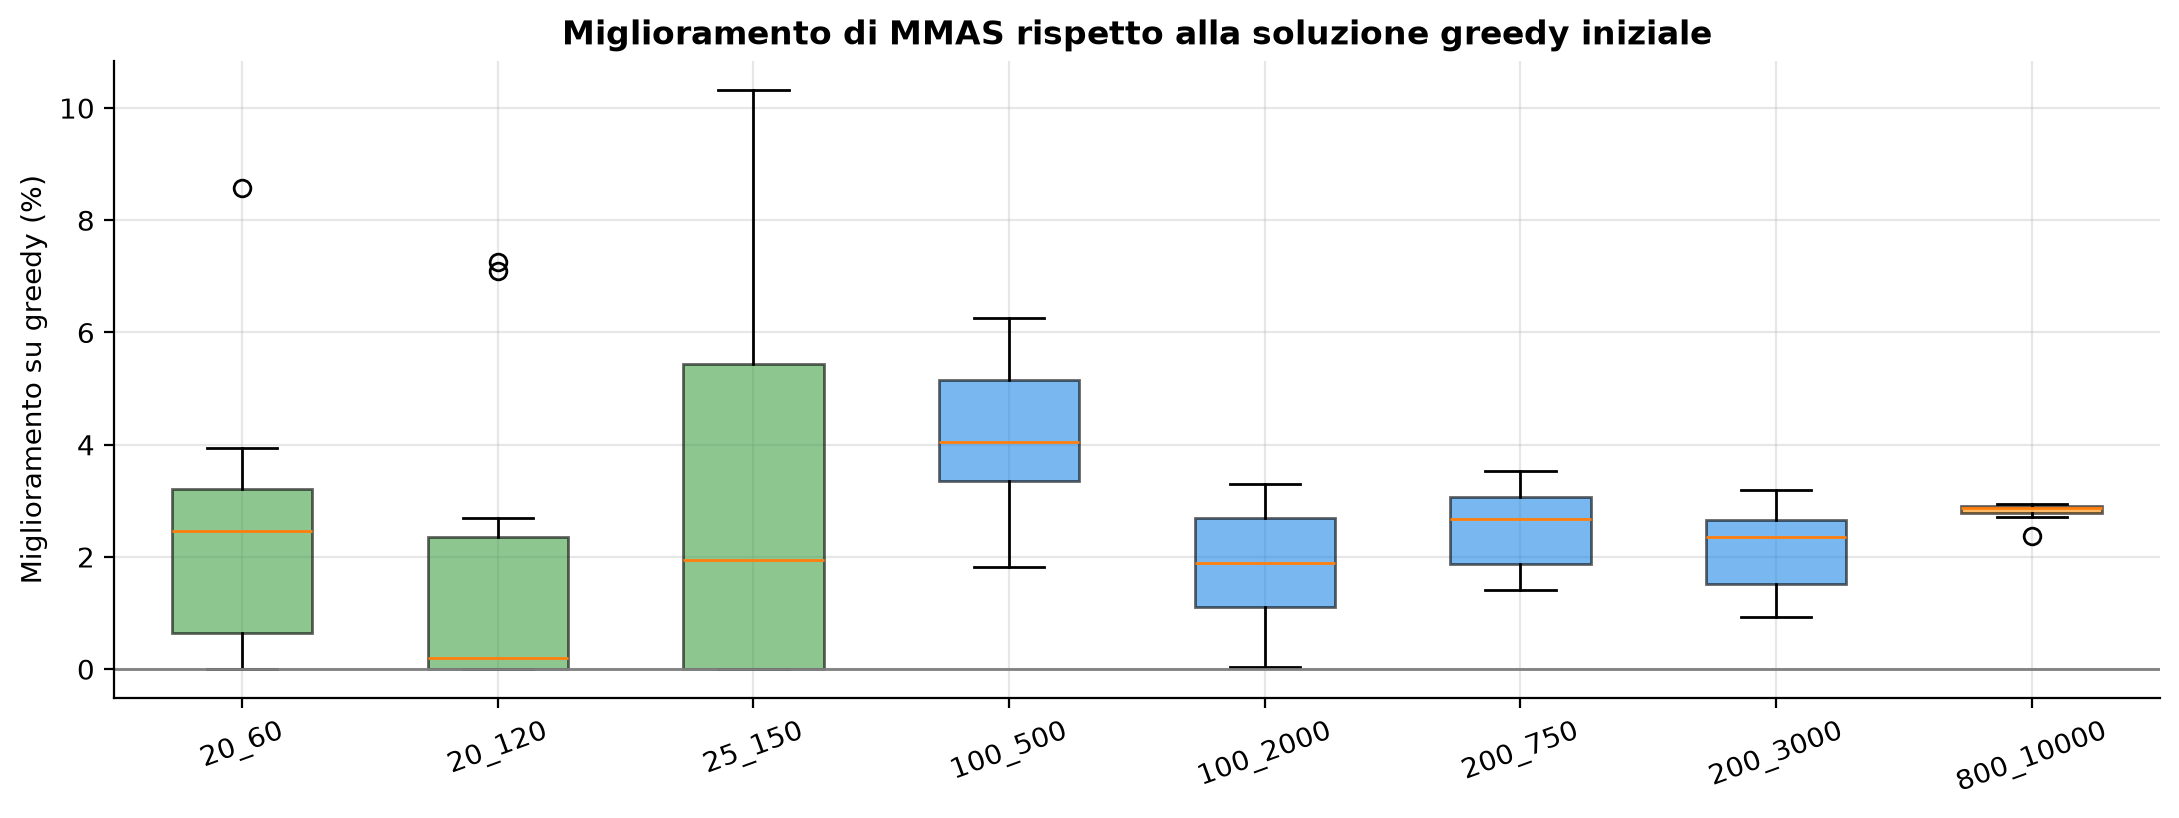

<sub>`results/plots/report_greedy_improvement.png` — caricato dal file salvato — dati: `vc_20_60.csv`, `vc_20_120.csv`, `vc_25_150.csv`, `vc_100_500.csv`, `vc_100_2000.csv`, `vc_200_750.csv`, `vc_200_3000.csv`, `vc_800_10000.csv`, `greedy_baseline.csv`</sub>

In [36]:
# --- Figure 3.x: grafici ricavati dai CSV del benchmark -------------------------
def build_boxplot(path):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), gridspec_kw={"width_ratios": [3, 4, 1.4]})
    for ax, c in zip(axes, CLASS_ORDER):
        cfgs = [p for p in META if META[p][0] == c]
        data = [bench.loc[bench["config"] == p, "best_weight"] for p in cfgs]
        bp = ax.boxplot(data, patch_artist=True, widths=0.55)
        for b in bp["boxes"]:
            b.set_facecolor(CLASS_COLORS[c]); b.set_alpha(0.6)
        ax.set_xticks(range(1, len(cfgs) + 1), [p.replace("vc_", "") for p in cfgs], rotation=15)
        unit = "10 run" if c == "LPI" else "10 istanze"
        ax.set_title(f"{c} ({unit} per box)", fontweight="bold")
        ax.set_ylabel("Peso della copertura w")
    fig.suptitle("Distribuzione delle migliori soluzioni per configurazione", fontweight="bold")
    fig.tight_layout(); save_fig(fig, path)

def build_fe_plots(path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    cfgs = list(META)
    data = [bench.loc[bench["config"] == p, "fe_at_best"] for p in cfgs]
    bp = axes[0].boxplot(data, patch_artist=True, widths=0.55)
    for b, p in zip(bp["boxes"], cfgs):
        b.set_facecolor(CLASS_COLORS[META[p][0]]); b.set_alpha(0.6)
    axes[0].set_yscale("log")
    axes[0].set_xticks(range(1, len(cfgs) + 1), [p.replace("vc_", "") for p in cfgs], rotation=30)
    axes[0].set_ylabel("FE al best (scala log)")
    axes[0].set_title("FE necessarie per trovare la migliore soluzione", fontweight="bold")
    bins = np.linspace(0, 100, 21)
    for c in CLASS_ORDER:
        axes[1].hist(bench.loc[bench["class"] == c, "fe_budget_pct"], bins=bins, alpha=0.6,
                     color=CLASS_COLORS[c], label=c, edgecolor="white")
    axes[1].set_xlabel("FE al best / FE_max (%)"); axes[1].set_ylabel("Numero di run")
    axes[1].set_title("Posizione del best nel budget", fontweight="bold"); axes[1].legend()
    fig.tight_layout(); save_fig(fig, path)

def build_scalability(path):
    agg = bench.groupby(["class", "config", "n"], as_index=False).agg(
        fe=("fe_at_best", "mean"), t=("time_seconds", "mean"))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for c in CLASS_ORDER:
        s = agg[agg["class"] == c]
        axes[0].scatter(s["n"], s["t"], s=70, color=CLASS_COLORS[c], label=c)
        axes[1].scatter(s["n"], s["fe"], s=70, color=CLASS_COLORS[c], label=c)
    for ax, lab, tit in [(axes[0], "Tempo medio per run (s)", "Tempo di esecuzione"),
                         (axes[1], "FE medie al best", "FE al best")]:
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel("|V|"); ax.set_ylabel(lab); ax.set_title(tit, fontweight="bold"); ax.legend()
    fig.suptitle("Scalabilità rispetto a |V| (una marca per configurazione, scala log-log)", fontweight="bold")
    fig.tight_layout(); save_fig(fig, path)

def build_greedy_plot(path):
    cfgs = list(META)
    fig, ax = plt.subplots(figsize=(11, 4.2))
    data = [bench.loc[bench["config"] == p, "impr_pct"] for p in cfgs]
    bp = ax.boxplot(data, patch_artist=True, widths=0.55)
    for b, p in zip(bp["boxes"], cfgs):
        b.set_facecolor(CLASS_COLORS[META[p][0]]); b.set_alpha(0.6)
    ax.axhline(0, color="gray", lw=1)
    ax.set_xticks(range(1, len(cfgs) + 1), [p.replace("vc_", "") for p in cfgs], rotation=20)
    ax.set_ylabel("Miglioramento su greedy (%)")
    ax.set_title("Miglioramento di MMAS rispetto alla soluzione greedy iniziale", fontweight="bold")
    fig.tight_layout(); save_fig(fig, path)

figure("report_boxplot_best_weight.png", "Figura 3.1 — Migliori soluzioni per configurazione",
       BENCH_CSVS, build_boxplot)
figure("report_fe_distribution.png", "Figura 3.2 — FE al best e posizione nel budget",
       BENCH_CSVS, build_fe_plots)
figure("report_scalability.png", "Figura 3.3 — Scalabilità: tempo e FE rispetto a |V|",
       BENCH_CSVS, build_scalability)
figure("report_greedy_improvement.png", "Figura 3.4 — Miglioramento rispetto al greedy",
       BENCH_CSVS + [greedy_csv], build_greedy_plot)

## 4. Convergenza

Le curve richiedono di rieseguire il solver (circa 30 minuti per ogni run LPI), quindi il notebook mostra
la figura salvata senza rigenerarla. Sotto la figura è riportato il riepilogo letto dal log dello stesso script,
per verificare che figura e dati corrispondano.

**Tabella 4.1 — Run usate per la Figura 4.1 (da plot_convergence.log)**

Istanza,Run,Media w ± σ,Min w,Max w,FE_best ± σ,Riferimento
vc_20_120_05.txt,10,997.0 ± 0.0,997,997,1.0 ± 0.0,OPT (ILP) = 997
vc_200_750_05.txt,10,8760.1 ± 2.8,8752,8761,1559.5 ± 3345.7,LB matching = 6341
vc_800_10000.txt,10,44528.2 ± 104.5,44439,44772,4642.8 ± 1272.3,LB matching = 26800


<sub>Seed 42–51. Nel log il bound è etichettato «Lower Bound LP», ma è calcolato da compute_lower_bound(), cioè dal matching greedy.</sub>

#### Figura 4.1 — Convergenza media (10 run, banda ±1σ) su un'istanza per classe

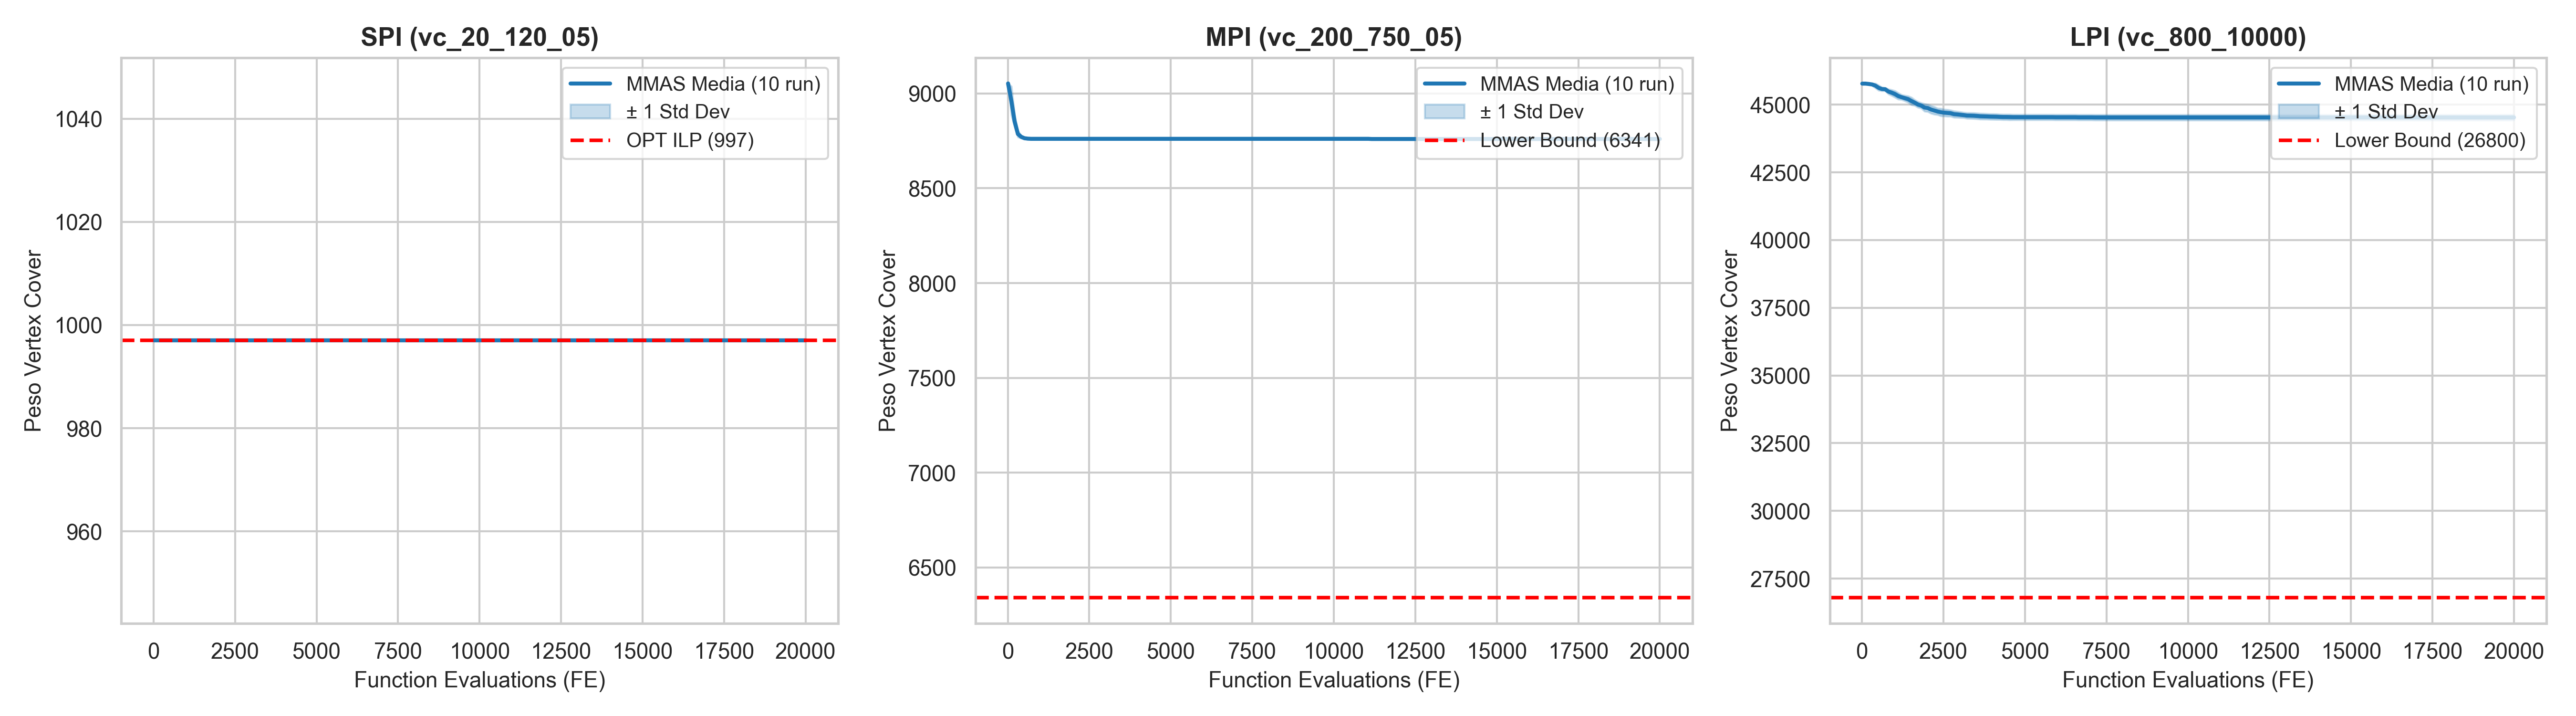

<sub>`results/plots/convergence_3_classes.png` — caricato dal file salvato — script: `python -m src.analysis.plot_convergence`</sub>

In [37]:
# --- Riepilogo dal log di src/analysis/plot_convergence.py ----------------------
conv_log = LOG_DIR / "plot_convergence.log"
rows, inst = [], None
if conv_log.exists():
    for line in conv_log.read_text(encoding="utf-8", errors="ignore").splitlines():
        m_i = re.search(r"Elaborazione istanza: (\S+)", line)
        m_r = re.search(r"\[Run (\d+)/(\d+)\] seed=(\d+) -> best_weight=(\d+) \(fe_at_best=(\d+)\)", line)
        m_ref = re.search(r"(Soluzione ILP trovata|Lower Bound LP): (\d+)", line)
        if m_i:
            inst, ref = m_i.group(1), None
        elif m_ref and inst:
            ref = (m_ref.group(1), int(m_ref.group(2)))
        elif m_r and inst:
            rows.append({"instance": inst, "seed": int(m_r.group(3)), "w": int(m_r.group(4)),
                         "fe": int(m_r.group(5)), "ref": ref})
conv = pd.DataFrame(rows)
if len(conv):
    out = []
    for i, s in conv.groupby("instance", sort=False):
        kind, val = s["ref"].iloc[0] if s["ref"].iloc[0] else ("—", np.nan)
        out.append({"Istanza": i, "Run": len(s), "Media w ± σ": pm(s["w"]),
                    "Min w": s["w"].min(), "Max w": s["w"].max(), "FE_best ± σ": pm(s["fe"]),
                    "Riferimento": ("OPT (ILP)" if "ILP" in kind else "LB matching") + f" = {val}"})
    show_table(pd.DataFrame(out), "Tabella 4.1 — Run usate per la Figura 4.1 (da plot_convergence.log)",
               "Seed 42–51. Nel log il bound è etichettato «Lower Bound LP», ma è calcolato da "
               "compute_lower_bound(), cioè dal matching greedy.")
else:
    print("Log di convergenza non trovato.")

figure("convergence_3_classes.png", "Figura 4.1 — Convergenza media (10 run, banda ±1σ) su un'istanza per classe",
       (), None, "python -m src.analysis.plot_convergence")

## 5. Tuning dei parametri

Il tuning è stato eseguito sull'istanza LPI `vc_800_10000` in tre passi:
**Fase 1** griglia completa su $\alpha,\beta,\rho$ con un solo seed; **validazione multi-seed** dei candidati migliori
(5 seed); **Fase 2** sensibilità a $N_{ants}$ con 5 seed, per $\rho=0.10$ e $\rho=0.15$.

**Tabella 5.1 — Fase 1: 16 configurazioni (α ∈ [1.0, 2.0], β ∈ [2.0, 5.0], ρ ∈ [0.02, 0.1, 0.15, 0.2]), seed 42**

Rank,α,β,ρ,N_ants,w,FE_best,Reset,Tempo (s)
1,1.0,2.0,0.15,80,44396,14364,5,1595.63
2,2.0,2.0,0.15,80,44409,13855,7,1670.33
3,1.0,2.0,0.10,80,44447,4049,8,1747.97
4,1.0,5.0,0.20,80,44457,17615,5,2406.92
5,2.0,5.0,0.15,80,44459,19990,5,2415.88
6,1.0,2.0,0.20,80,44463,7615,7,1635.68
7,1.0,5.0,0.15,80,44467,15528,6,2431.54
8,2.0,2.0,0.20,80,44470,17831,6,1629.54
9,2.0,5.0,0.02,80,44477,7305,6,2522.34
10,2.0,5.0,0.10,80,44484,19790,7,2470.32


<sub>Una sola run per configurazione: le differenze di poche decine di unità di peso sono dello stesso ordine della variabilità tra seed (vedi Tabella 5.2).</sub>

#### Figura 5.1 — Fase 1: griglia completa

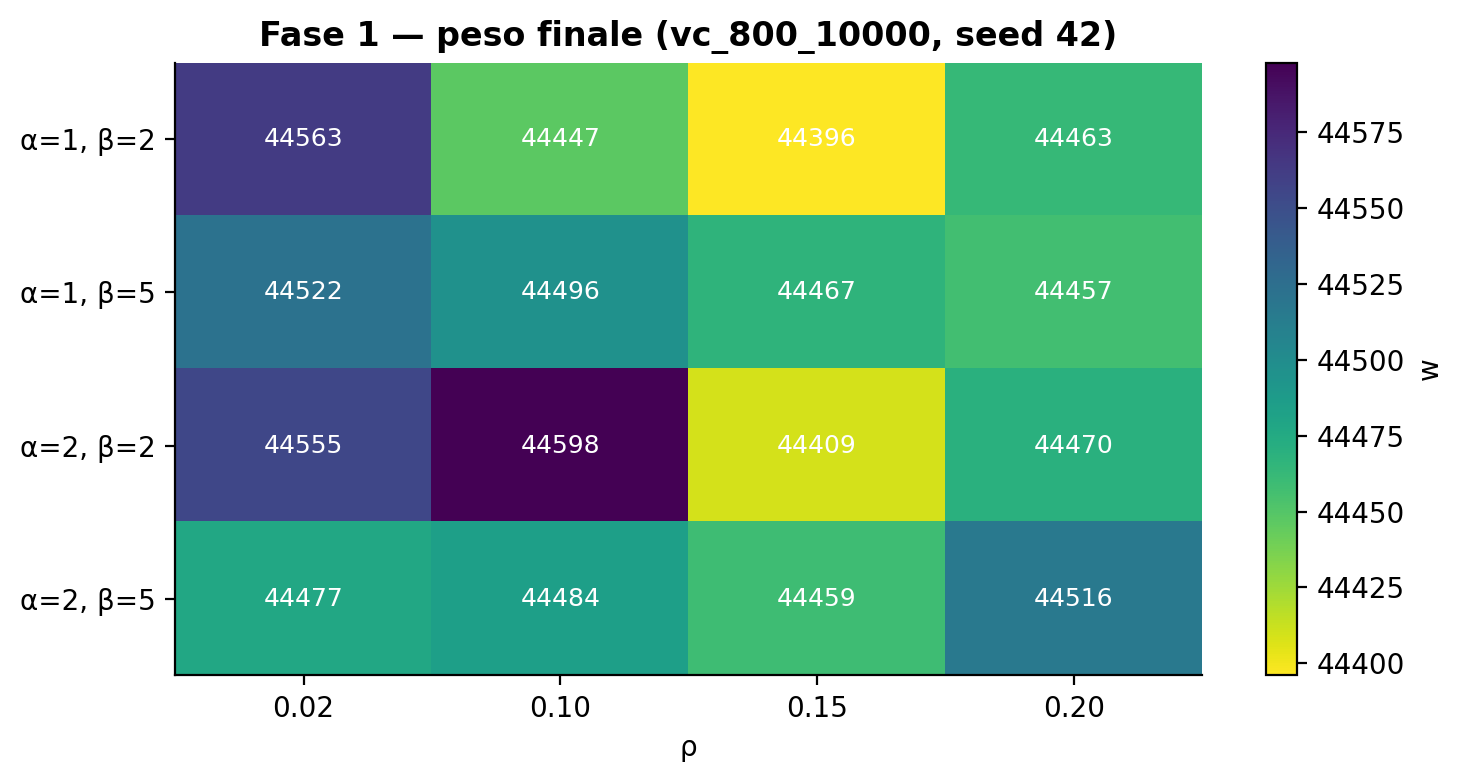

<sub>`results/plots/report_tuning_phase1_heatmap.png` — caricato dal file salvato — dati: `tuning_results.csv` — script: `src/tune_parameters.py`</sub>

In [38]:
# --- 5.1 Fase 1: griglia alpha x beta x rho (seed 42, N_ants = 80) --------------
tun_csv = CSV_DIR / "tuning_results.csv"
tun = pd.read_csv(tun_csv)
ph1 = tun[tun["phase"] == "FASE 1"].copy()
grid_desc = (f"α ∈ {sorted(ph1.alpha.unique().tolist())}, β ∈ {sorted(ph1.beta.unique().tolist())}, "
             f"ρ ∈ {sorted(ph1.rho.unique().tolist())}")
t51 = (ph1.sort_values(["best_weight", "fe_best"])
          .assign(Rank=lambda d: range(1, len(d) + 1))
          [["Rank", "alpha", "beta", "rho", "n_ants", "best_weight", "fe_best", "reinits", "time_s"]]
          .rename(columns={"alpha": "α", "beta": "β", "rho": "ρ", "n_ants": "N_ants", "best_weight": "w",
                           "fe_best": "FE_best", "reinits": "Reset", "time_s": "Tempo (s)"}))
show_table(t51, f"Tabella 5.1 — Fase 1: {len(ph1)} configurazioni ({grid_desc}), seed 42",
           "Una sola run per configurazione: le differenze di poche decine di unità di peso sono dello stesso "
           "ordine della variabilità tra seed (vedi Tabella 5.2).")

def build_phase1_heatmap(path):
    piv = ph1.pivot_table(index=["alpha", "beta"], columns="rho", values="best_weight")
    fig, ax = plt.subplots(figsize=(7.5, 4))
    im = ax.imshow(piv.values, cmap="viridis_r", aspect="auto")
    ax.set_xticks(range(piv.shape[1]), [f"{c:.2f}" for c in piv.columns])
    ax.set_yticks(range(piv.shape[0]), [f"α={a:g}, β={b:g}" for a, b in piv.index])
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            ax.text(j, i, f"{piv.values[i, j]:.0f}", ha="center", va="center", color="white", fontsize=9)
    ax.set_xlabel("ρ"); ax.grid(False)
    ax.set_title("Fase 1 — peso finale (vc_800_10000, seed 42)", fontweight="bold")
    fig.colorbar(im, ax=ax, label="w"); fig.tight_layout(); save_fig(fig, path)

figure("report_tuning_phase1_heatmap.png", "Figura 5.1 — Fase 1: griglia completa", [tun_csv],
       build_phase1_heatmap, "src/tune_parameters.py", width=650)

**Tabella 5.2 — Validazione multi-seed dei candidati (vc_800_10000, seed 42/101/202/303/404)**

Rank,α,β,ρ,N_ants,Seed,Media w ± σ,Min w,Max w,FE_best ± σ,Tempo medio (s)
1,1.0,2.0,0.15,60,5,44419.4 ± 34.1,44379,44458,13247 ± 4283,1624.6
2,1.0,2.0,0.10,80,5,44450.6 ± 26.2,44409,44473,4136 ± 651,1677.6
3,1.0,2.0,0.15,80,5,44454.2 ± 35.5,44396,44493,13672 ± 5446,1731.7
4,1.0,5.0,0.15,80,5,44463.8 ± 23.2,44442,44501,15466 ± 6367,1522.1
5,2.0,2.0,0.15,80,5,44495.6 ± 72.3,44409,44584,15009 ± 4252,1680.2


<sub>σ con ddof=1.</sub>

#### Figura 5.2 — Candidati multi-seed: qualità e FE al best

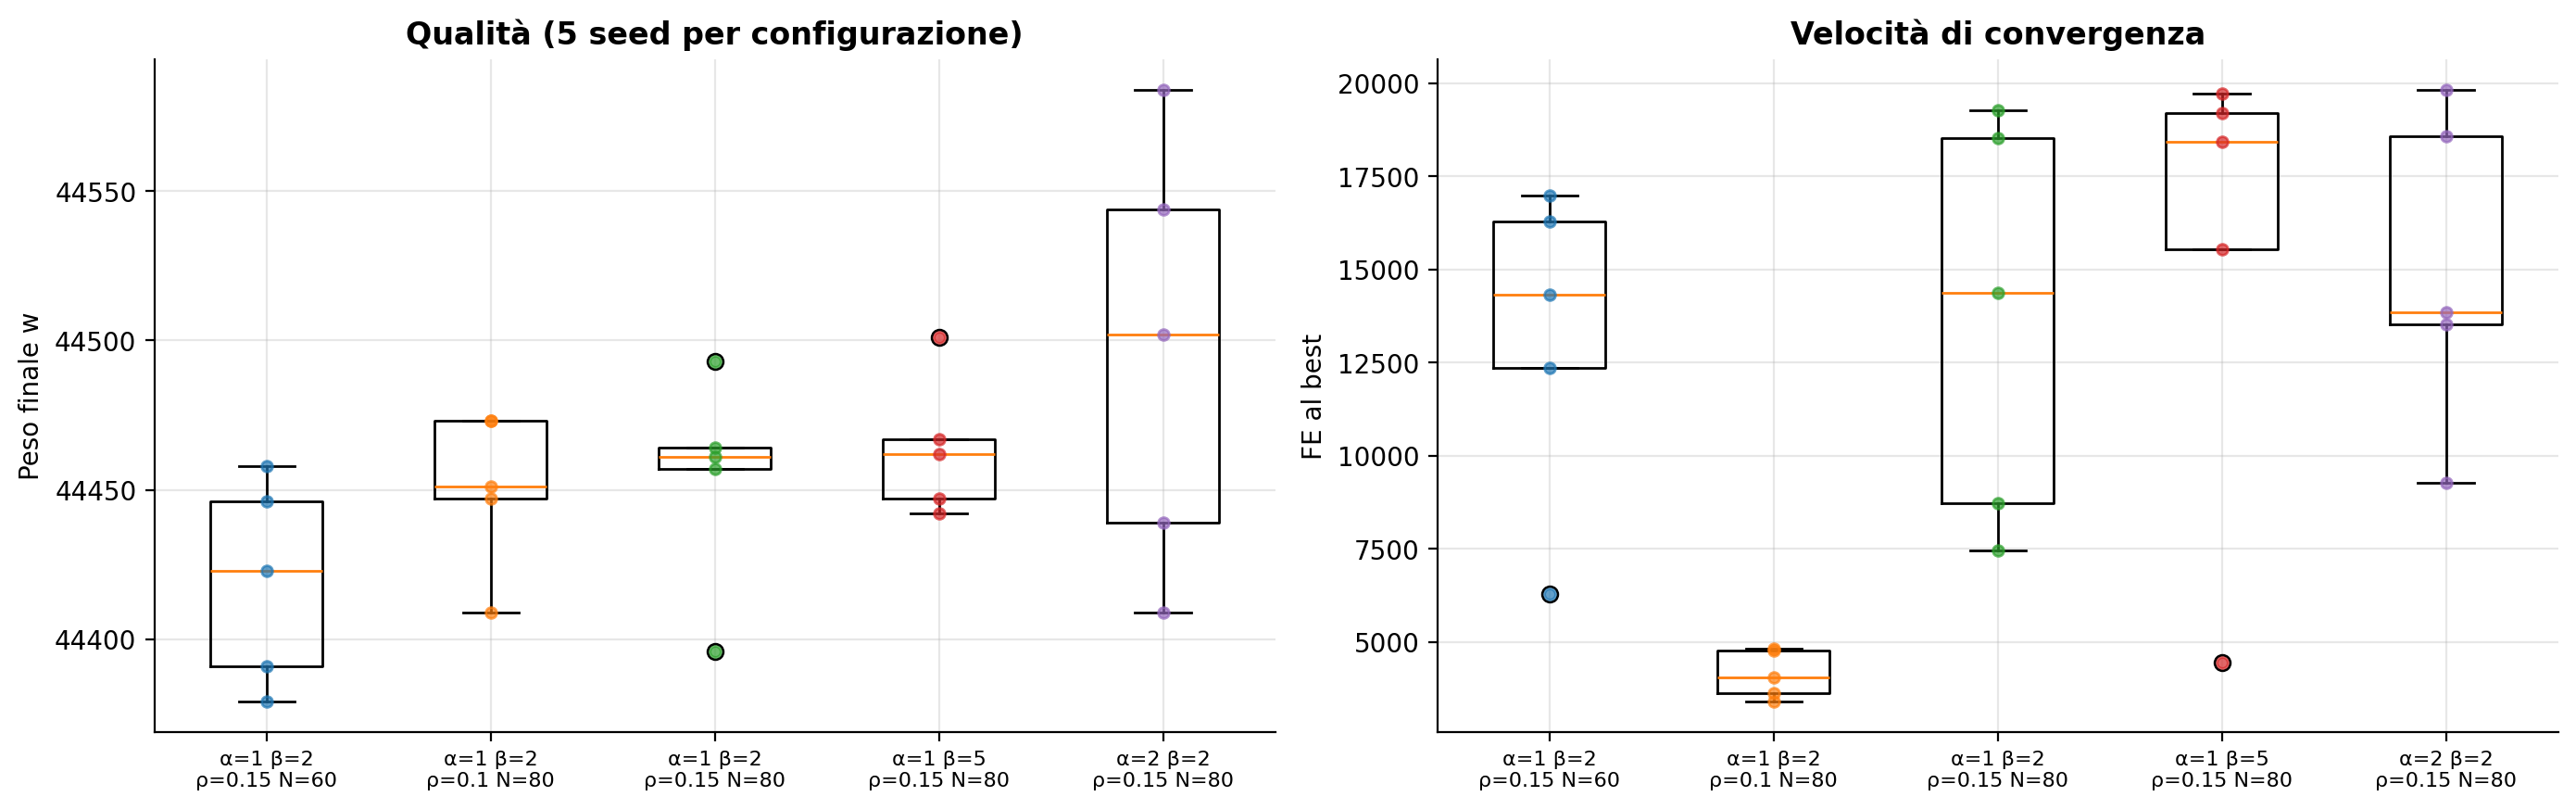

<sub>`results/plots/report_tuning_multiseed.png` — caricato dal file salvato — dati: `multiseed_top_candidates.csv` — script: `src/run_multiseed_validation.py`</sub>

In [39]:
# --- 5.2 Validazione multi-seed dei candidati (5 seed) --------------------------
ms_csv = CSV_DIR / "multiseed_top_candidates.csv"
ms = pd.read_csv(ms_csv)
rows = []
for (a, b, r, na), g in ms.groupby(["alpha", "beta", "rho", "n_ants"]):
    rows.append({"α": a, "β": b, "ρ": r, "N_ants": na, "Seed": len(g),
                 "_m": g.best_weight.mean(), "Media w ± σ": pm(g.best_weight),
                 "Min w": g.best_weight.min(), "Max w": g.best_weight.max(),
                 "FE_best ± σ": pm(g.fe_best, 0), "Tempo medio (s)": round(g.time_s.mean(), 1)})
t52 = pd.DataFrame(rows).sort_values("_m").drop(columns="_m")
t52.insert(0, "Rank", range(1, len(t52) + 1))
show_table(t52, "Tabella 5.2 — Validazione multi-seed dei candidati (vc_800_10000, seed 42/101/202/303/404)",
           f"σ con ddof={DDOF}.")

def build_multiseed_plot(path):
    keys = [tuple(k) for k in ms.groupby(["alpha", "beta", "rho", "n_ants"]).groups]
    keys.sort(key=lambda k: ms[(ms.alpha == k[0]) & (ms.beta == k[1]) & (ms.rho == k[2]) & (ms.n_ants == k[3])].best_weight.mean())
    labels = [f"α={a:g} β={b:g}\nρ={r:g} N={n}" for a, b, r, n in keys]
    sel = [ms[(ms.alpha == a) & (ms.beta == b) & (ms.rho == r) & (ms.n_ants == n)] for a, b, r, n in keys]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, col, lab in [(axes[0], "best_weight", "Peso finale w"), (axes[1], "fe_best", "FE al best")]:
        ax.boxplot([s[col] for s in sel], widths=0.5)
        for i, s in enumerate(sel, start=1):
            ax.scatter(np.full(len(s), i), s[col], s=18, alpha=0.7, zorder=3)
        ax.set_xticks(range(1, len(keys) + 1), labels, fontsize=8); ax.set_ylabel(lab)
    axes[0].set_title("Qualità (5 seed per configurazione)", fontweight="bold")
    axes[1].set_title("Velocità di convergenza", fontweight="bold")
    fig.tight_layout(); save_fig(fig, path)

figure("report_tuning_multiseed.png", "Figura 5.2 — Candidati multi-seed: qualità e FE al best", [ms_csv],
       build_multiseed_plot, "src/run_multiseed_validation.py")

**Tabella 5.3 — Sensibilità a N_ants con ρ = 0.10 (α=1, β=2, 5 seed)**

N_ants,Iterazioni,Media w ± σ,Min w,Max w,FE_best ± σ,Reset medi
40,500,44451.8 ± 32.5,44396,44477,9837 ± 5193,7.0
60,333,44448.8 ± 34.6,44409,44504,7795 ± 5408,6.8
80,250,44450.6 ± 26.2,44409,44473,4136 ± 651,7.6
120,166,44490.8 ± 38.4,44442,44538,6056 ± 668,5.4
160,125,44525.6 ± 156.7,44409,44798,7488 ± 1545,3.8


<sub>σ con ddof=1. N_ants = 80 corrisponde alla regola max(5, ⌊n/10⌋) per n = 800.</sub>

**Tabella 5.3 — Sensibilità a N_ants con ρ = 0.15 (α=1, β=2, 5 seed)**

N_ants,Iterazioni,Media w ± σ,Min w,Max w,FE_best ± σ,Reset medi
40,500,44463.0 ± 27.3,44442,44510,14735 ± 3766,6.8
60,333,44419.4 ± 34.1,44379,44458,13247 ± 4283,6.0
80,250,44454.2 ± 35.5,44396,44493,13672 ± 5446,6.6
120,166,44586.2 ± 121.0,44461,44733,3840 ± 502,6.2
160,125,44504.0 ± 67.5,44417,44599,7283 ± 3946,3.6


<sub>σ con ddof=1. N_ants = 80 corrisponde alla regola max(5, ⌊n/10⌋) per n = 800.</sub>

#### Figura 5.3 — Sensibilità a N_ants

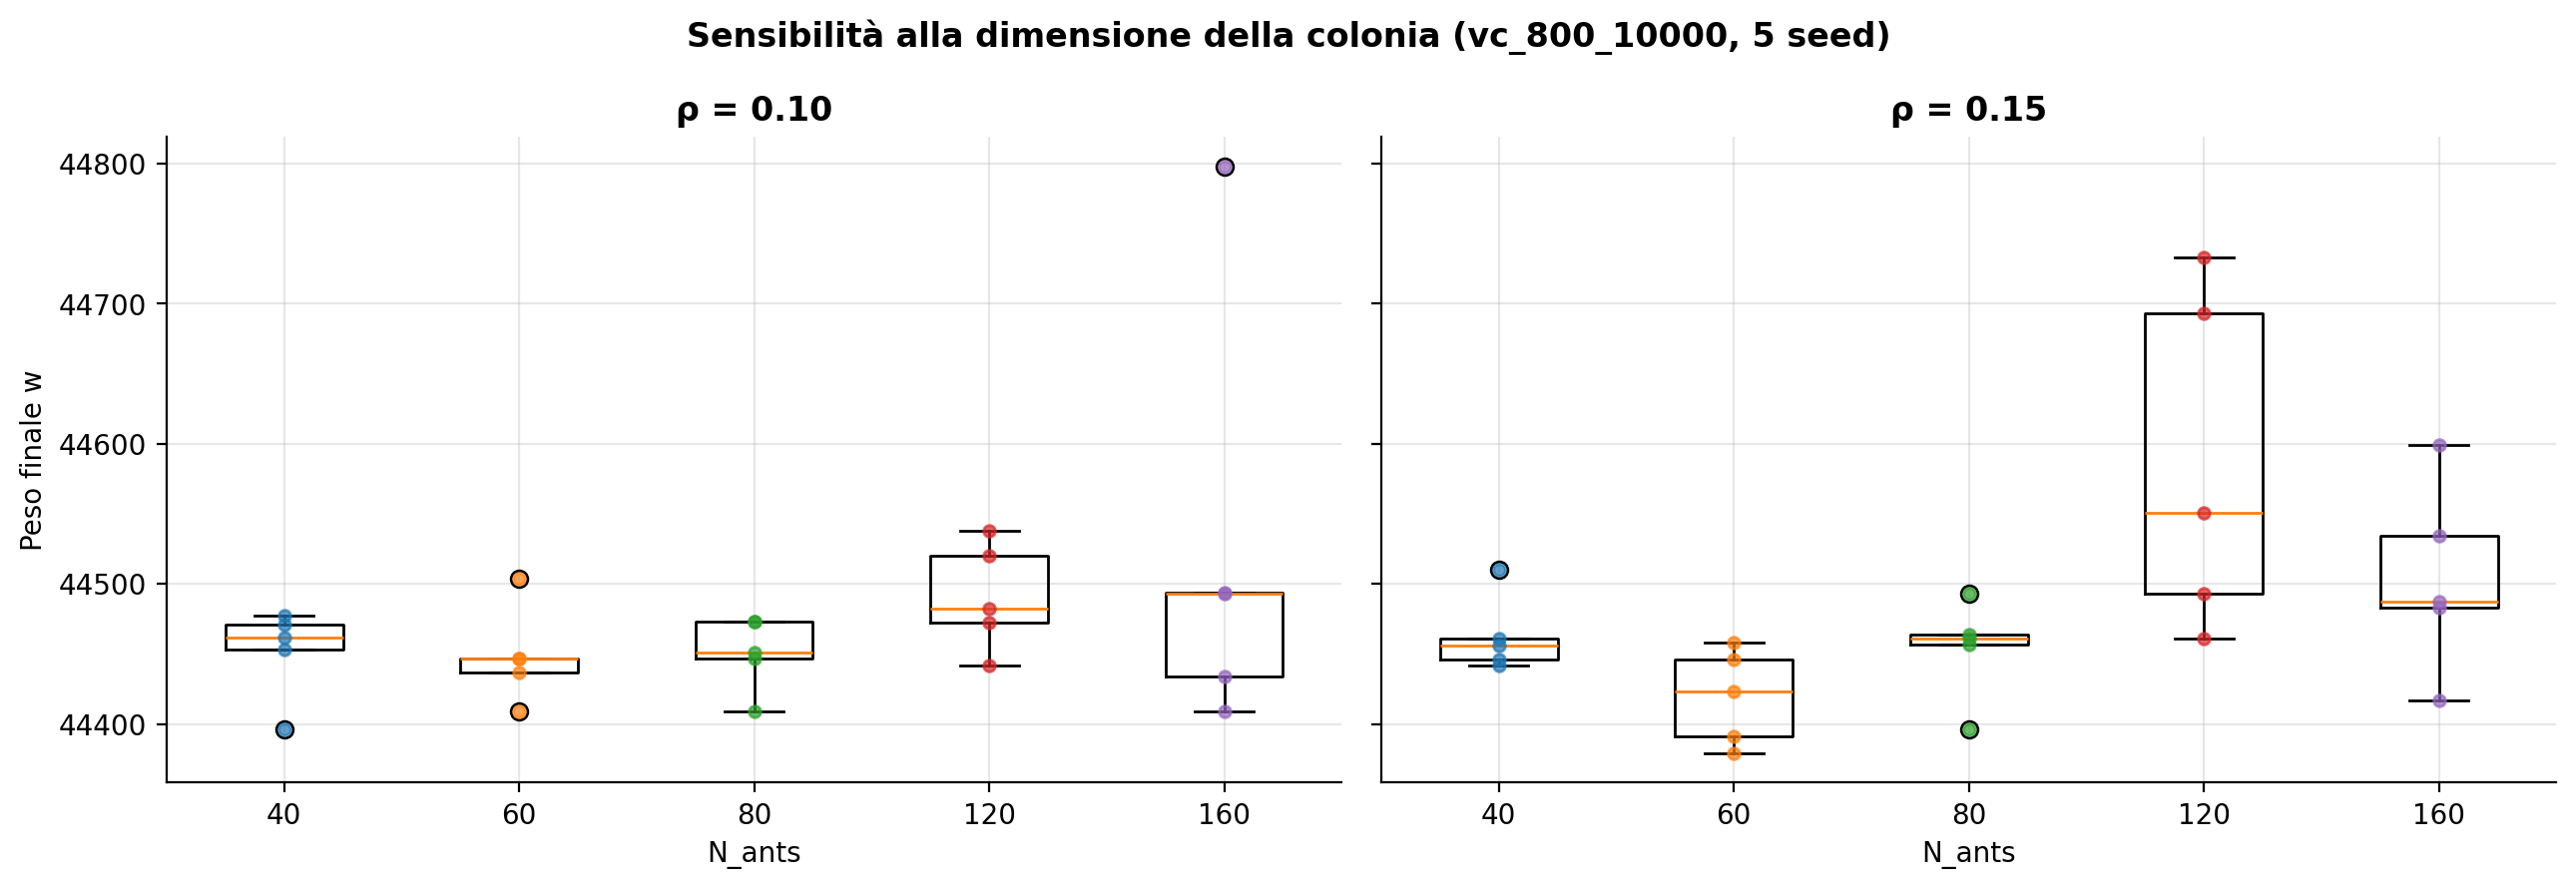

<sub>`results/plots/report_population_sensitivity.png` — caricato dal file salvato — dati: `multiseed_population_results.csv` — script: `src/run_multiseed_population.py`</sub>

In [40]:
# --- 5.3 Fase 2: dimensione della colonia N_ants (5 seed) -----------------------
pop_csv = CSV_DIR / "multiseed_population_results.csv"
pop = pd.read_csv(pop_csv)
for r in sorted(pop.rho.unique()):
    rows = []
    for na, g in pop[pop.rho == r].groupby("n_ants"):
        rows.append({"N_ants": na, "Iterazioni": FE_MAX // na, "Media w ± σ": pm(g.best_weight),
                     "Min w": g.best_weight.min(), "Max w": g.best_weight.max(),
                     "FE_best ± σ": pm(g.fe_best, 0), "Reset medi": round(g.reinits.mean(), 1)})
    show_table(pd.DataFrame(rows), f"Tabella 5.3 — Sensibilità a N_ants con ρ = {r:.2f} (α=1, β=2, 5 seed)",
               f"σ con ddof={DDOF}. N_ants = 80 corrisponde alla regola max(5, ⌊n/10⌋) per n = 800.")

def build_population_plot(path):
    rhos = sorted(pop.rho.unique())
    fig, axes = plt.subplots(1, len(rhos), figsize=(13, 4.5), sharey=True)
    for ax, r in zip(np.atleast_1d(axes), rhos):
        s = pop[pop.rho == r]
        ns = sorted(s.n_ants.unique())
        ax.boxplot([s[s.n_ants == n].best_weight for n in ns], widths=0.5)
        for i, n in enumerate(ns, start=1):
            ax.scatter(np.full((s.n_ants == n).sum(), i), s[s.n_ants == n].best_weight, s=18, alpha=0.7, zorder=3)
        ax.set_xticks(range(1, len(ns) + 1), ns); ax.set_xlabel("N_ants")
        ax.set_title(f"ρ = {r:.2f}", fontweight="bold")
    np.atleast_1d(axes)[0].set_ylabel("Peso finale w")
    fig.suptitle("Sensibilità alla dimensione della colonia (vc_800_10000, 5 seed)", fontweight="bold")
    fig.tight_layout(); save_fig(fig, path)

figure("report_population_sensitivity.png", "Figura 5.3 — Sensibilità a N_ants", [pop_csv],
       build_population_plot, "src/run_multiseed_population.py")

## 6. Ablation

### 6.1 Modalità di scelta della soluzione guida (`gb_switch_mode`)
Quattro modalità a confronto su `vc_800_10000` (α=1, β=2, N_ants=80, 5 seed), per ρ = 0.10 e ρ = 0.15:
`cycle` (proposta), `fixed_budget` (switch al 75% del budget), `never` (solo $S_{ib}$), `always` (solo $S_{gb}$).

**Tabella 6.1 — Modalità di switch, ρ = 0.10**

Rank,Modalità,Media w ± σ,Min w,Max w,FE_best ± σ
1,fixed_budget,44435.4 ± 21.0,44409,44457,11648 ± 7239
2,cycle,44450.6 ± 26.2,44409,44473,4136 ± 651
3,never,44450.6 ± 26.2,44409,44473,4136 ± 651
4,always,44592.8 ± 129.4,44472,44749,12173 ± 5448


<sub>σ con ddof=1. Modalità con risultati identici seed per seed: cycle = never.</sub>

**Tabella 6.1 — Modalità di switch, ρ = 0.15**

Rank,Modalità,Media w ± σ,Min w,Max w,FE_best ± σ
1,never,44441.2 ± 49.9,44396,44516,14361 ± 1418
2,fixed_budget,44443.6 ± 51.9,44396,44516,15032 ± 2024
3,cycle,44454.2 ± 35.5,44396,44493,13672 ± 5446
4,always,44616.4 ± 163.9,44493,44891,13943 ± 2996


<sub>σ con ddof=1. Modalità con risultati identici seed per seed: nessuna.</sub>

#### Figura 6.1 — Modalità di switch

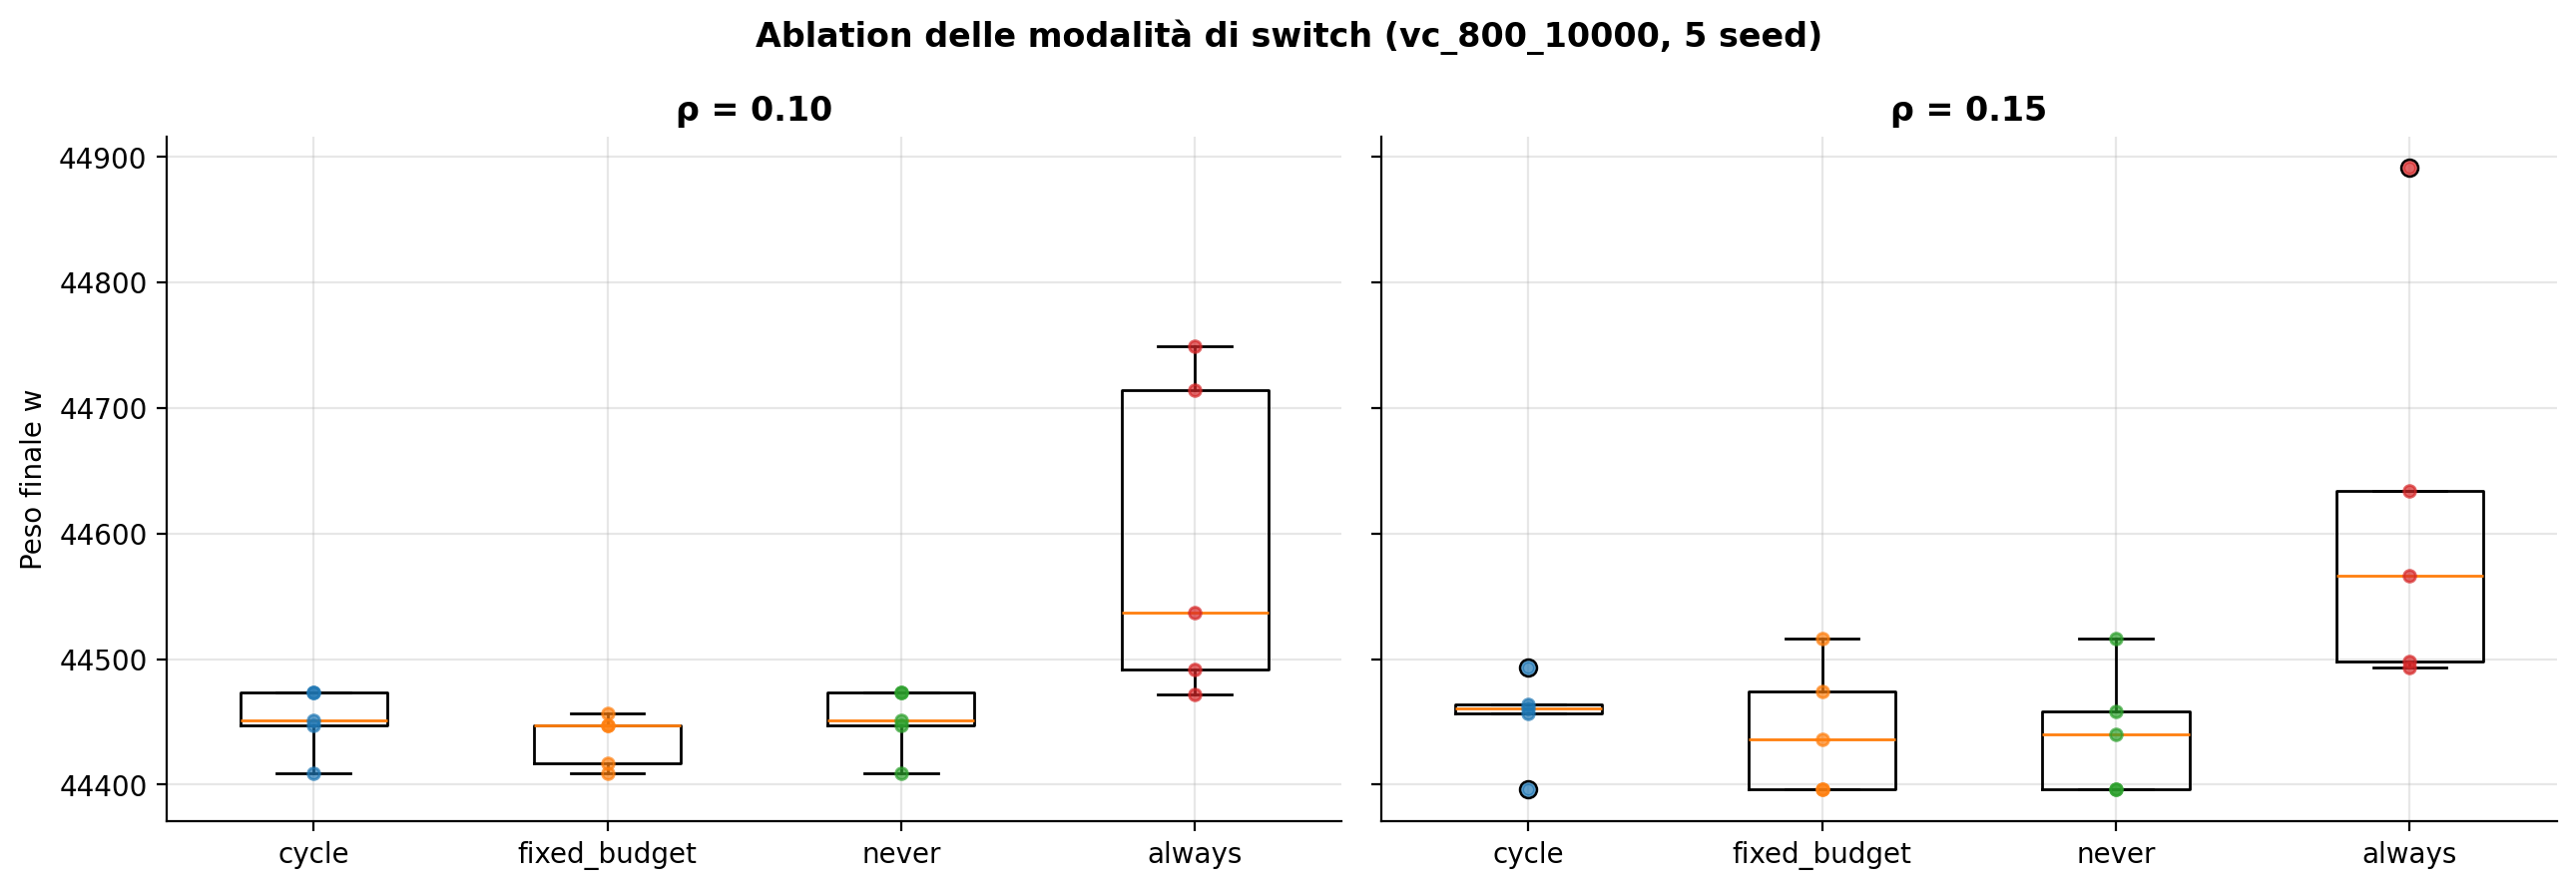

<sub>`results/plots/report_ablation_switch.png` — caricato dal file salvato — dati: `ablation_switch_results.csv` — script: `src/run_ablation_switch.py`</sub>

In [41]:
abl_csv = CSV_DIR / "ablation_switch_results.csv"
abl = pd.read_csv(abl_csv)
MODE_ORDER = ["cycle", "fixed_budget", "never", "always"]
for r in sorted(abl.rho.unique()):
    s = abl[abl.rho == r]
    rows = []
    for mode in MODE_ORDER:
        g = s[s["mode"] == mode]
        rows.append({"Modalità": mode, "_m": g.best_weight.mean(), "Media w ± σ": pm(g.best_weight),
                     "Min w": g.best_weight.min(), "Max w": g.best_weight.max(),
                     "FE_best ± σ": pm(g.fe_best, 0)})
    t = pd.DataFrame(rows).sort_values("_m").drop(columns="_m")
    t.insert(0, "Rank", range(1, len(t) + 1))
    # confronto seed per seed tra le modalità
    piv = s.pivot_table(index="seed", columns="mode", values="best_weight")
    same = [f"{a} = {b}" for i, a in enumerate(MODE_ORDER) for b in MODE_ORDER[i + 1:]
            if a in piv and b in piv and (piv[a] == piv[b]).all()]
    show_table(t, f"Tabella 6.1 — Modalità di switch, ρ = {r:.2f}",
               f"σ con ddof={DDOF}. Modalità con risultati identici seed per seed: "
               + (", ".join(same) if same else "nessuna") + ".")

def build_switch_plot(path):
    rhos = sorted(abl.rho.unique())
    fig, axes = plt.subplots(1, len(rhos), figsize=(13, 4.5), sharey=True)
    for ax, r in zip(axes, rhos):
        s = abl[abl.rho == r]
        ax.boxplot([s[s["mode"] == m].best_weight for m in MODE_ORDER], widths=0.5)
        for i, m in enumerate(MODE_ORDER, start=1):
            v = s[s["mode"] == m].best_weight
            ax.scatter(np.full(len(v), i), v, s=18, alpha=0.7, zorder=3)
        ax.set_xticks(range(1, 5), MODE_ORDER); ax.set_title(f"ρ = {r:.2f}", fontweight="bold")
    axes[0].set_ylabel("Peso finale w")
    fig.suptitle("Ablation delle modalità di switch (vc_800_10000, 5 seed)", fontweight="bold")
    fig.tight_layout(); save_fig(fig, path)

figure("report_ablation_switch.png", "Figura 6.1 — Modalità di switch", [abl_csv],
       build_switch_plot, "src/run_ablation_switch.py")

### 6.2 Ablation delle componenti
Varianti: MMAS completo, senza reset per stagnazione, senza pruning, senza feromone (α=0), senza euristica (β=0).
Lo script non salva un CSV: i valori per seed vengono letti dal log `results/log/plot_ablation.log`, usando per ogni
istanza l'ultima esecuzione completa e non interrotta; la media ricalcolata viene confrontata con quella scritta nel log.

In [42]:
abl_log = LOG_DIR / "plot_ablation.log"
blocks, cur, variant = [], None, None
for line in abl_log.read_text(encoding="utf-8", errors="ignore").splitlines():
    m_start = re.search(r"Avvio Ablation Study su (\S+) \((\d+) seed", line)
    m_var   = re.search(r"Valutazione variante: '(.+)'", line)
    m_run   = re.search(r"\[Run (\d+)/(\d+)\] seed=(\d+) -> best_weight=(\d+)", line)
    m_ok    = re.search(r"\[OK\] Variante '(.+)' completata: ([\d.]+) ± ([\d.]+)", line)
    if m_start:
        cur = {"instance": m_start.group(1), "n_seeds": int(m_start.group(2)), "runs": [], "ok": []}
        blocks.append(cur); variant = None
    elif cur is None:
        continue
    elif m_var:
        variant = m_var.group(1)
    elif m_run and variant:
        cur["runs"].append({"variant": variant, "seed": int(m_run.group(3)), "w": int(m_run.group(4)),
                            "tot": int(m_run.group(2))})
    elif m_ok:
        cur["ok"].append((m_ok.group(1), float(m_ok.group(2)), float(m_ok.group(3))))

def block_valid(b):
    # blocco completo: 5 varianti, ognuna con n_seeds run, e medie coerenti con le righe [OK]
    if len(b["ok"]) != 5:
        return False
    r = pd.DataFrame(b["runs"])
    if r.empty or (r["tot"] != b["n_seeds"]).any():
        return False
    for name, mean_log, _ in b["ok"]:
        w = r.loc[r.variant == name, "w"]
        if len(w) != b["n_seeds"] or abs(w.mean() - mean_log) > 0.06:
            return False
    return True

valid = {}
for b in blocks:
    if block_valid(b):
        valid[(b["instance"], b["n_seeds"])] = b          # tiene l'ultimo blocco valido

abl_comp = []
for (inst, ns), b in valid.items():
    for r in b["runs"]:
        abl_comp.append({"instance": inst, "n_seeds": ns, **{k: r[k] for k in ("variant", "seed", "w")}})
abl_comp = pd.DataFrame(abl_comp)

VAR_ORDER = ["MMAS Completo", "Senza Recovery", "Senza Pruning", "No Feromone (α=0)", "No Euristica (β=0)"]
for (inst, ns), s in abl_comp.groupby(["instance", "n_seeds"], sort=False):
    base = s[s.variant == "MMAS Completo"].w.mean()
    rows = []
    for v in VAR_ORDER:
        w = s[s.variant == v].w
        rows.append({"Variante": v, "Media w ± σ": pm(w), "Min w": w.min(), "Max w": w.max(),
                     "Δ vs completo (%)": round((w.mean() - base) / base * 100, 2)})
    show_table(pd.DataFrame(rows), f"Tabella 6.2 — Ablation delle componenti su {inst} ({ns} seed: 42–{41 + ns})",
               f"σ con ddof={DDOF} (il log usa ddof=0). Δ > 0 = variante peggiore del completo.")

**Tabella 6.2 — Ablation delle componenti su vc_200_3000_05.txt (10 seed: 42–51)**

Variante,Media w ± σ,Min w,Max w,Δ vs completo (%)
MMAS Completo,11518.1 ± 6.1,11515,11534,0.00
Senza Recovery,11518.1 ± 6.1,11515,11534,0.00
Senza Pruning,11563.9 ± 15.0,11546,11585,0.40
No Feromone (α=0),11520.0 ± 9.3,11515,11540,0.02
No Euristica (β=0),11531.6 ± 12.4,11515,11545,0.12


<sub>σ con ddof=1 (il log usa ddof=0). Δ > 0 = variante peggiore del completo.</sub>

**Tabella 6.2 — Ablation delle componenti su vc_800_10000.txt (10 seed: 42–51)**

Variante,Media w ± σ,Min w,Max w,Δ vs completo (%)
MMAS Completo,44514.3 ± 110.5,44428,44770,0.00
Senza Recovery,44514.3 ± 110.5,44428,44770,0.00
Senza Pruning,46155.0 ± 0.0,46155,46155,3.69
No Feromone (α=0),45518.6 ± 55.9,45439,45594,2.26
No Euristica (β=0),44733.0 ± 157.6,44549,44942,0.49


<sub>σ con ddof=1 (il log usa ddof=0). Δ > 0 = variante peggiore del completo.</sub>

**Tabella 6.2 — Ablation delle componenti su vc_800_10000.txt (5 seed: 42–46)**

Variante,Media w ± σ,Min w,Max w,Δ vs completo (%)
MMAS Completo,44495.2 ± 78.7,44428,44619,0.00
Senza Recovery,44495.2 ± 78.7,44428,44619,0.00
Senza Pruning,46155.0 ± 0.0,46155,46155,3.73
No Feromone (α=0),45522.0 ± 37.7,45487,45583,2.31
No Euristica (β=0),44742.2 ± 157.2,44576,44928,0.56


<sub>σ con ddof=1 (il log usa ddof=0). Δ > 0 = variante peggiore del completo.</sub>

In [43]:
# --- Verifica: la variante «Senza Recovery» disattiva davvero il reset? ----------
from src.core.mmas import MMAS_Solver
init_src  = inspect.getsource(MMAS_Solver.__init__)
solve_src = inspect.getsource(MMAS_Solver.solve)
stored = "self.max_reinits" in init_src
local_calc = re.search(r"^\s*max_reinits\s*=", solve_src, re.M) is not None
display(Markdown(
    "**Verifica del parametro `max_reinits`** (usato dallo script di ablation per la variante «Senza Recovery»)\n\n"
    f"- memorizzato nel costruttore (`self.max_reinits`): **{'sì' if stored else 'no'}**\n"
    f"- ricalcolato dentro `solve()` ignorando il valore passato: **{'sì' if local_calc else 'no'}**\n\n"
    + ("➜ Il valore passato da `plot_ablation.py` non ha effetto: «Senza Recovery» esegue lo stesso codice di "
       "«MMAS Completo», da cui i risultati identici seed per seed. Il contributo del reset non è quindi misurato."
       if (not stored and local_calc) else "➜ Il parametro viene usato.")))

**Verifica del parametro `max_reinits`** (usato dallo script di ablation per la variante «Senza Recovery»)

- memorizzato nel costruttore (`self.max_reinits`): **no**
- ricalcolato dentro `solve()` ignorando il valore passato: **sì**

➜ Il valore passato da `plot_ablation.py` non ha effetto: «Senza Recovery» esegue lo stesso codice di «MMAS Completo», da cui i risultati identici seed per seed. Il contributo del reset non è quindi misurato.

#### Figura 6.2 — Ablation delle componenti

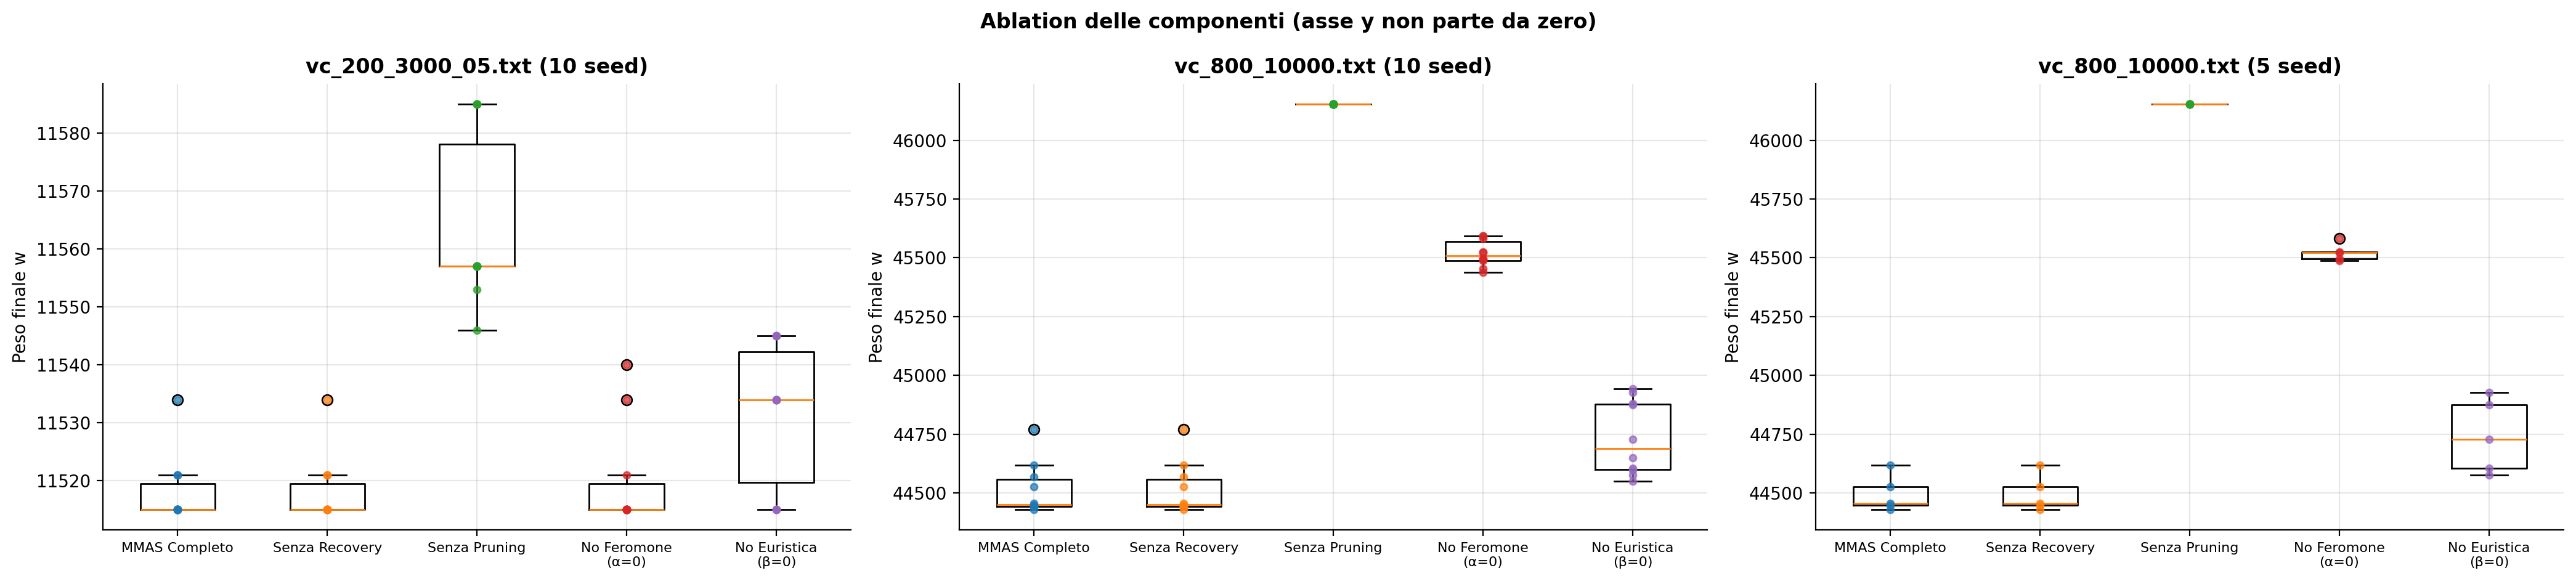

<sub>`results/plots/report_ablation_components.png` — caricato dal file salvato — dati: `plot_ablation.log` — script: `python -m src.analysis.plot_ablation`</sub>

In [44]:
def build_components_plot(path):
    groups = list(abl_comp.groupby(["instance", "n_seeds"], sort=False))
    fig, axes = plt.subplots(1, len(groups), figsize=(7 * len(groups), 4.8))
    for ax, ((inst, ns), s) in zip(np.atleast_1d(axes), groups):
        ax.boxplot([s[s.variant == v].w for v in VAR_ORDER], widths=0.5)
        for i, v in enumerate(VAR_ORDER, start=1):
            w = s[s.variant == v].w
            ax.scatter(np.full(len(w), i), w, s=16, alpha=0.7, zorder=3)
        ax.set_xticks(range(1, 6), [v.replace(" (", "\n(") for v in VAR_ORDER], fontsize=8)
        ax.set_title(f"{inst} ({ns} seed)", fontweight="bold"); ax.set_ylabel("Peso finale w")
    fig.suptitle("Ablation delle componenti (asse y non parte da zero)", fontweight="bold")
    fig.tight_layout(); save_fig(fig, path)

figure("report_ablation_components.png", "Figura 6.2 — Ablation delle componenti", [abl_log],
       build_components_plot, "python -m src.analysis.plot_ablation")

## 7. Sintesi dei risultati
Testo generato dai dati: se i CSV cambiano, anche questa sintesi si aggiorna.

In [45]:
spi = bench[bench["class"] == "SPI"]; mpi = bench[bench["class"] == "MPI"]; lpi = bench[bench["class"] == "LPI"]
best_ms = t52.iloc[0]
cfg_final = ms[(ms.alpha == 1.0) & (ms.beta == 2.0) & (ms.rho == 0.10) & (ms.n_ants == 80)]
cyc = abl[(abl.rho == 0.10)]
txt = f'''
**Configurazione usata nel benchmark:** α = 1.0, β = 2.0, ρ = 0.10, N_ants = max(5, ⌊n/10⌋), FE_max = {FE_MAX:,}.

- **SPI** ({len(spi)} istanze): ottimo ILP raggiunto in **{int(spi.opt_hit.sum())}/{len(spi)}** casi;
  FE_best medio {spi.fe_at_best.mean():.1f}; in {int(spi.greedy_is_best.sum())}/{len(spi)} casi la soluzione greedy iniziale era già ottima.
- **MPI** ({len(mpi)} istanze): gap medio dal LB (matching) {mpi.gap_pct_lb.mean():.1f}%;
  FE_best medio {mpi.fe_at_best.mean():.0f}; miglioramento medio sul greedy {mpi.impr_pct.mean():.2f}%.
- **LPI** (10 run): w = {pm(lpi.best_weight)} (min {lpi.best_weight.min()}); FE_best = {pm(lpi.fe_at_best, 0)};
  miglioramento sul greedy {lpi.impr_pct.mean():.2f}%.
- **Tuning (5 seed, LPI):** migliore media α={best_ms['α']:g}, β={best_ms['β']:g}, ρ={best_ms['ρ']:g},
  N_ants={best_ms['N_ants']} con {best_ms['Media w ± σ']}; la configurazione usata (ρ=0.10, N=80) ottiene
  {pm(cfg_final.best_weight)} con FE_best {pm(cfg_final.fe_best, 0)}.
- **Switch (ρ=0.10):** '''
for mode in MODE_ORDER:
    g = cyc[cyc["mode"] == mode].best_weight
    txt += f"`{mode}` {pm(g)}; "
display(Markdown(txt))


**Configurazione usata nel benchmark:** α = 1.0, β = 2.0, ρ = 0.10, N_ants = max(5, ⌊n/10⌋), FE_max = 20,000.

- **SPI** (30 istanze): ottimo ILP raggiunto in **30/30** casi;
  FE_best medio 6.9; in 12/30 casi la soluzione greedy iniziale era già ottima.
- **MPI** (40 istanze): gap medio dal LB (matching) 59.1%;
  FE_best medio 3048; miglioramento medio sul greedy 2.65%.
- **LPI** (10 run): w = 44489.9 ± 78.9 (min 44428); FE_best = 5777 ± 4955;
  miglioramento sul greedy 2.81%.
- **Tuning (5 seed, LPI):** migliore media α=1, β=2, ρ=0.15,
  N_ants=60 con 44419.4 ± 34.1; la configurazione usata (ρ=0.10, N=80) ottiene
  44450.6 ± 26.2 con FE_best 4136 ± 651.
- **Switch (ρ=0.10):** `cycle` 44450.6 ± 26.2; `fixed_budget` 44435.4 ± 21.0; `never` 44450.6 ± 26.2; `always` 44592.8 ± 129.4; 

## Appendice A — Figure in `results/plots/` non usate in questo report
Elenco generato controllando i file presenti; le motivazioni sono verificabili nel codice indicato.

In [46]:
used = {"convergence_3_classes.png"} | {p.name for p in PLOTS_DIR.glob("report_*.png")}
reasons = {
    "convergence_runs_3_classes.png":
        "Non corrisponde al codice attuale di plot_convergence_runs.py: lo script usa vc_20_120_05 (OPT 997) e "
        "vc_200_750_05 (tutte le run a 8761 nel log di convergenza), la figura mostra OPT 844 e run tra circa 7 600 e 8 300.",
    "convergence_band.png": "Copia di convergence_runs_3_classes.png (stesso file).",
    "improvement_vs_time_trajectory.png":
        "Curve costruite per interpolazione esponenziale tra peso greedy e peso finale "
        "(generate_improvement_plots.py, funzione run_single_trajectory_task): non sono traiettorie misurate.",
    "improvement_time_tradeoff_bars.png": "Valori letti dalle stesse curve interpolate.",
    "improvement_histogram_by_config.png":
        "Pannello 1 e 3 da valori reali; sostituito dalle Figure 5.2 e 3.4 calcolate dai CSV.",
    "ablation_study_plot.png":
        "Nessuno script in src/ la produce; titolo «LPI» ma pesi tra 3 000 e 9 000 (LPI ≈ 44 500) "
        "e una curva best-so-far che risale.",
    "ablation_study.png": "Copia dell'ultima esecuzione di plot_ablation (5 seed); sostituita dalla Figura 6.2.",
    "ablation_study_lpi.png": "Stessi dati della Figura 6.2 (LPI, 10 seed), asse y da zero.",
    "ablation_study_lpi_5run.png": "Esecuzione a 5 seed; la Figura 6.2 usa quella a 10 seed.",
    "ablation_study_mpi.png": "Stessi dati della Figura 6.2 (MPI, 10 seed), asse y da zero.",
    "boxplot_best_weight.png": "Generata prima dell'ultimo aggiornamento dei CSV; sostituita dalla Figura 3.1.",
    "fe_vs_weight.png": "Generata prima dell'ultimo aggiornamento dei CSV; sostituita dalla Figura 3.2.",
    "budget_distribution.png": "Generata prima dell'ultimo aggiornamento dei CSV; sostituita dalla Figura 3.2.",
    "scalability_scatter.png": "Generata prima dell'ultimo aggiornamento dei CSV e solo sulle FE; sostituita dalla Figura 3.3.",
    "population_sensitivity.png": "Nessuno script in src/ la produce; sostituita dalla Figura 5.3.",
    "tuning_heatmap.png": "Costruita su 5 configurazioni, non sulla griglia completa; sostituita dalla Figura 5.1.",
}
rows = [{"File": p.name, "Motivo": reasons.get(p.name, "—")}
        for p in sorted(PLOTS_DIR.glob("*.png")) if p.name not in used]
show_table(pd.DataFrame(rows), "Tabella A.1 — Figure non incluse")

**Tabella A.1 — Figure non incluse**

File,Motivo
ablation_study.png,Copia dell'ultima esecuzione di plot_ablation (5 seed); sostituita dalla Figura 6.2.
ablation_study_lpi.png,"Stessi dati della Figura 6.2 (LPI, 10 seed), asse y da zero."
ablation_study_lpi_5run.png,Esecuzione a 5 seed; la Figura 6.2 usa quella a 10 seed.
ablation_study_mpi.png,"Stessi dati della Figura 6.2 (MPI, 10 seed), asse y da zero."
ablation_study_plot.png,Nessuno script in src/ la produce; titolo «LPI» ma pesi tra 3 000 e 9 000 (LPI ≈ 44 500) e una curva best-so-far che risale.
boxplot_best_weight.png,Generata prima dell'ultimo aggiornamento dei CSV; sostituita dalla Figura 3.1.
budget_distribution.png,Generata prima dell'ultimo aggiornamento dei CSV; sostituita dalla Figura 3.2.
convergence_band.png,Copia di convergence_runs_3_classes.png (stesso file).
convergence_runs_3_classes.png,"Non corrisponde al codice attuale di plot_convergence_runs.py: lo script usa vc_20_120_05 (OPT 997) e vc_200_750_05 (tutte le run a 8761 nel log di convergenza), la figura mostra OPT 844 e run tra circa 7 600 e 8 300."
fe_vs_weight.png,Generata prima dell'ultimo aggiornamento dei CSV; sostituita dalla Figura 3.2.
